# EWC 2026 PUBG rank prediction

Self-contained notebook (no local package dependency) for Kaggle. Crawls Twire tournament stats + power rankings, scrapes Liquipedia EWC 2026 rosters, engineers weighted team features, and trains a RandomForest to predict EWC finish rank.

In [1]:
%pip install -q requests beautifulsoup4 tqdm scikit-learn matplotlib pandas numpy python-dotenv

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import unicodedata
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)


/Users/qnrj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/qnrj/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [3]:
# --- Twire GraphQL API --------------------------------------------------------

import os

try:
    from dotenv import load_dotenv
    load_dotenv("../.env")
except ImportError:
    pass

API_URL = "https://tjjkdyimqrb7jjnc6m5rpefjtu.appsync-api.eu-west-1.amazonaws.com/graphql"

# Local: copy ../.env.example to ../.env and fill in the key.
# Kaggle: Add-ons -> Secrets -> TWIRE_API_KEY, then os.environ["TWIRE_API_KEY"] = user_secrets.get_secret("TWIRE_API_KEY")
TWIRE_API_KEY = os.environ.get("TWIRE_API_KEY")

if not TWIRE_API_KEY:
    raise RuntimeError(
        "TWIRE_API_KEY is not set. Copy .env.example to .env in the project "
        "root and fill in the key, or export TWIRE_API_KEY in your shell/"
        "Kaggle secrets."
    )

HEADERS = {
    "x-api-key": TWIRE_API_KEY,
    "Content-Type": "application/json",
    "Origin": "https://twire.gg",
    "Referer": "https://twire.gg/",
}

GAME = "pubg"


In [4]:
# --- Twire static assets (S3) -------------------------------------------------

TEAM_RANKING_URL = "https://twire-assets.s3.eu-west-1.amazonaws.com/pubg/team-ranking/team-ranking.json"
POWER_RANKING_URL = "https://twire-assets.s3.eu-west-1.amazonaws.com/pubg/power-ranking/power-ranking.json"
POWER_RANKING_YEAR = "2026"

# Power-ranking tournament tiers: keyed by substring of the ranking's
# tournament slug (e.g. "2026-pgs-1", "pcl-26-spring", "enc-player-ranking").
POWER_TOURNAMENT_WEIGHTS = {
    "pgs": 1.0,
    "enc": 1.0,
}
POWER_TOURNAMENT_DEFAULT_WEIGHT = 0.6  # regional: pms, pec, pvs, pas, pts, pws, pcl


In [5]:
# --- Liquipedia ----------------------------------------------------------------

LIQUIPEDIA_URL = "https://liquipedia.net/pubg/Esports_World_Cup/2026"

LIQUIPEDIA_HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

TEAM_NAME_MAP = {
    "AGAL International": "Anyone's Legend",
    "GAM The Expendables": "The Expendables",
    "FULL SENSE": "Full Sense",
    "R8 Esports": "VEGA ESPORTS",
    "Shadow Esport": "SHADOW ESPORT",
    "Sharper Esports": "Sharper Esport",
    "Team Nemesis": "TEAM NEMESIS"
}

In [6]:
# --- Tournaments -----------------------------------------------------------------

TOURNAMENTS = {
    "PGS1": {
        "id": 2473,  # Replace with actual tournament ID from tournaments.csv
        "name": "2026 PGS 1",
        "year": 2026,
        "uuid": "66bbb080-2224-11f1-8444-6adabec81c44",
    },
    "PGS2": {
        "id": 2488,  # Replace with actual ID
        "name": "2026 PGS 2",
        "year": 2025,
        "uuid": "4702993a-28f4-11f1-9125-6adabec81c44",
    },
    "PGS3": {
        "id": 2500,  # Replace with actual ID
        "name": "2026 PGS 3",
        "year": 2025,
        "uuid": "13d20004-2e72-11f1-9dc9-6adabec81c44",
    },
    "PGS4": {
        "id": 2543,  # Replace with actual ID
        "name": "2026 PGS 4",
        "year": 2025,
        "uuid": "31054c04-540a-11f1-af22-6adabec81c44",
    },
    "PGS5": {
        "id": 2551,
        "name": "2026 PGS 5",
        "year": 2026,
        "uuid": "9c951222-5a2e-11f1-9004-6adabec81c44",
    },
    "PGS6": {
        "id": 2550,  # Replace with actual tournament ID from tournaments.csv
        "name": "2026 PGS 6",
        "year": 2026,
        "uuid": "9c702f34-5a2e-11f1-8257-6adabec81c44",
    },
    "PWS": {
        "id": 2538,
        "name": "PUBG WEEKLY SERIES 2026 Phase 1",
        "year": 2026,
        "uuid": "897c012e-4b0a-11f1-8f54-6adabec81c44",
    },
    "PCL": {
        "id": 2536,
        "name": "PUBG Champions League 2026 - Spring",
        "year": 2026,
        "uuid": "8c1c3332-4a3c-11f1-a2c0-6adabec81c44",
    },
    "PEC": {
        "id": 2512,
        "name": "PEC: Spring Playoffs & Finals",
        "year": 2026,
        "uuid": "709f733c-3a81-11f1-8bfc-6adabec81c44",
    },
    "PTS": {
        "id": 2530,
        "name": "PUBG Thailand Series 2026 - Phase 1",
        "year": 2026,
        "uuid": "513a00d2-42ee-11f1-bab5-6adabec81c44",
    },
    "PAS": {
        "id": 2513,
        "name": "PAS1 Playoffs & Finals",
        "year": 2026,
        "uuid": "c2e622ae-3aad-11f1-93de-6adabec81c44",
    },
    "PVS": {
        "id": 2510,
        "name": "PVS 2026 Phase 1",
        "year": 2026,
        "uuid": "afc03272-3810-11f1-b6ee-6adabec81c44",
    },
    "PMS": {
        "id": 2400,
        "name": "PUBG Master Series 2026: Phase 1",
        "year": 2026,
        "uuid": "ec23e36e-dc10-11f0-85d2-064f26ad4164",
    },
}

In [7]:
# Tournament importance, keyed by each tournament's actual `name` (matches
# team_df["tournament"] / the Twire API's tournamentName) rather than its
# short code -- short codes like "PMS"/"PWS"/"PCL"/"PTS" don't appear as
# substrings of the real tournament names ("PUBG Master Series 2026: Phase 1"
# etc.), so keying on them silently fell through to the 1.0 default weight
# for those tournaments. Deriving from TOURNAMENTS[key]["name"] keeps this
# in sync automatically.
_PGS_WEIGHTS = {
    "PGS1": 0.80,
    "PGS2": 0.90,
    "PGS3": 1.00,
    "PGS4": 1.10,
    "PGS5": 1.20,
    "PGS6": 1.30,
}
_REGIONAL_DEFAULT_WEIGHT = 0.60

TOURNAMENT_WEIGHTS = {
    TOURNAMENTS[key]["name"]: _PGS_WEIGHTS.get(key, _REGIONAL_DEFAULT_WEIGHT)
    for key in TOURNAMENTS
}

# 6 individual PGS tiers (0.80-1.30) + 1 shared regional tier (0.60) = 7.
TOTAL_TOURNAMENT_TIERS = len(set(TOURNAMENT_WEIGHTS.values()))

# Stage importance
STAGE_WEIGHTS = {
    "Grand Finals": 1.30,
    "Final Stage": 1.30,
    "Winners Stage": 1.15,
    "Group Stage": 1.00,
    "Survival Stage": 0.95,
}


In [8]:
# --- Output --------------------------------------------------------------------
# "../output" so it lands in the project-root output/ dir, not notebooks/output/
# (Jupyter's cwd is wherever this notebook file lives).

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Normalization & weighting helpers

In [9]:
def get_tournament_weight(name):
    for key, weight in TOURNAMENT_WEIGHTS.items():
        if key.lower() in str(name).lower():
            return weight
    return 1.0


def get_stage_weight(name):
    for key, weight in STAGE_WEIGHTS.items():
        if key.lower() in str(name).lower():
            return weight
    return 0.6


def get_power_tournament_weight(tournament):
    for key, weight in POWER_TOURNAMENT_WEIGHTS.items():
        if key.lower() in str(tournament).lower():
            return weight
    return POWER_TOURNAMENT_DEFAULT_WEIGHT


In [10]:
def normalize_team(name):
    if pd.isna(name):
        return name

    name = str(name).strip()

    # remove duplicate spaces
    name = re.sub(r"\s+", " ", name)

    # remove spaces in names beginning with numbers
    # 17 Gaming -> 17Gaming
    name = re.sub(r"^(\d+)\s+", r"\1", name)

    return name


def normalize_player(name):
    if pd.isna(name):
        return name

    name = str(name).strip()

    # Take everything after the first underscore
    if "_" in name:
        name = name.split("_", 1)[1]

    return name

## 1. Twire tournament stats (GraphQL)

In [11]:
GET_FILTERS = """
query ($id: Int!, $game: String!) {
  tournamentInitialData(id: $id, game: $game) {
    tournament {
      friendlyName
    }
    tournamentFilters {
      name
      value
    }
  }
}
"""

TEAM_STATS_QUERY = """
query ($shardInfo:String!, $game:String!) {
  teamStats(
    shardInfo:$shardInfo,
    token:"",
    filters:null,
    game:$game
  ) {

    tournamentName
    groupName
    matchName

    teamStats {

      teamName
      teamLogo

      stats {

        map
        rank
        kills
        assists
        damageDealt
        damageTaken
        points
        totalPoints
        wins
        avgKills
        avgDamageDealt
        avgRank
        avgPoints
      }
    }
  }
}
"""

PLAYER_STATS_QUERY = """
query ($shardInfo:String!, $game:String!) {
  platformStats(
    tournament:$shardInfo,
    token:"",
    filters:null,
    game:$game
  ) {

    tournamentName
    groupName
    matchName

    leaderboard {

      username
      teamName

      kills
      assists

      kd
      kas

      damageDealt
      damageTaken

      avgDamageDealt
      avgDamageTaken

      deaths

      dbnos

      revives

      headshotKills

      walkDistance
      rideDistance

      longestKill

      avgTimeSurvived

      numOfMatches
    }
  }
}
"""

In [12]:
def graphql(query, variables=None):
    payload = {
        "query": query,
        "variables": variables or {}
    }

    r = requests.post(API_URL, headers=HEADERS, json=payload)

    print("Status:", r.status_code)

    try:
        return r.json()
    except Exception:
        print(r.text)
        return None

In [13]:
def fetch_shard_infos(tournaments):
    """Resolve each tournament's stage filters into GraphQL shardInfo strings."""

    all_filters = {}

    for key, t in tournaments.items():

        result = graphql(GET_FILTERS, {"id": t["id"], "game": GAME})

        if result is None or "errors" in result:
            print("❌ Error")
            continue

        if result["data"]["tournamentInitialData"] is None:
            print("❌ No tournamentInitialData")
            continue

        all_filters[key] = result["data"]["tournamentInitialData"]["tournamentFilters"]

    shard_infos = {}

    for tournament, filters in all_filters.items():

        uuid = tournaments[tournament]["uuid"]

        shard_infos[tournament] = []

        for f in filters:

            shard_infos[tournament].append({
                "stage": f["name"],
                "value": f["value"],
                "shardInfo": f"{uuid}-{f['value']}"
            })

    return shard_infos

In [14]:
shard_infos = fetch_shard_infos(TOURNAMENTS)
shard_infos.keys()

Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200


dict_keys(['PGS1', 'PGS2', 'PGS3', 'PGS4', 'PGS5', 'PGS6', 'PWS', 'PCL', 'PEC', 'PTS', 'PAS', 'PVS', 'PMS'])

In [15]:
def fetch_team_stats_raw(shard_infos):
    team_stats_raw = []

    for tournament, stages in tqdm(shard_infos.items()):

        for stage in stages:

            data = graphql(
                TEAM_STATS_QUERY,
                {
                    "shardInfo": stage["shardInfo"],
                    "game": GAME
                }
            )

            team_stats_raw.append({
                "tournament": tournament,
                "stage": stage["stage"],
                "data": data["data"]["teamStats"]
            })

    return team_stats_raw


team_stats_raw = fetch_team_stats_raw(shard_infos)
len(team_stats_raw)

  0%|          | 0/13 [00:00<?, ?it/s]

Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200


  8%|▊         | 1/13 [00:08<01:40,  8.38s/it]

Status: 200
Status: 200
Status: 200


 15%|█▌        | 2/13 [00:12<01:04,  5.90s/it]

...

 92%|█████████▏| 12/13 [01:41<00:08,  8.44s/it]

Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200


100%|██████████| 13/13 [02:06<00:00,  9.74s/it]

Status: 200


100

In [16]:
def fetch_player_stats_raw(shard_infos):
    player_stats_raw = []

    for tournament, stages in tqdm(shard_infos.items()):

        for stage in stages:

            data = graphql(
                PLAYER_STATS_QUERY,
                {
                    "shardInfo": stage["shardInfo"],
                    "game": GAME
                }
            )

            player_stats_raw.append({
                "tournament": tournament,
                "stage": stage["stage"],
                "data": data["data"]["platformStats"]
            })

    return player_stats_raw


player_stats_raw = fetch_player_stats_raw(shard_infos)
len(player_stats_raw)

  0%|          | 0/13 [00:00<?, ?it/s]

Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200


  8%|▊         | 1/13 [00:06<01:16,  6.36s/it]

Status: 200
Status: 200
Status: 200


 15%|█▌        | 2/13 [00:09<00:52,  4.74s/it]

...

 92%|█████████▏| 12/13 [01:28<00:06,  6.86s/it]

Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200


100%|██████████| 13/13 [01:54<00:00,  8.79s/it]

Status: 200


100

In [17]:
def build_team_df(team_stats_raw):
    rows = []

    for tournament in team_stats_raw:

        info = tournament["data"]

        for team in info["teamStats"]:

            for stat in team["stats"]:

                row = {
                    "tournament": info["tournamentName"],
                    "stage": info["groupName"],
                    "team": team["teamName"],
                    **stat
                }

                rows.append(row)

    return pd.DataFrame(rows)


team_df = build_team_df(team_stats_raw)
team_df.shape

(7966, 16)

In [18]:
def build_player_df(player_stats_raw):
    rows = []

    for tournament in player_stats_raw:

        info = tournament["data"]

        for player in info["leaderboard"]:

            player["tournament"] = info["tournamentName"]
            player["stage"] = info["groupName"]

            rows.append(player)

    return pd.DataFrame(rows)


player_df = build_player_df(player_stats_raw)
player_df.shape

(6647, 21)

In [19]:
def apply_weights(df):
    """Attach tournament/stage importance weights (used by all weighted averages)."""

    df["tournament_weight"] = df["tournament"].apply(get_tournament_weight)
    df["stage_weight"] = df["stage"].apply(get_stage_weight)
    df["weight"] = (
        df["tournament_weight"]
        * df["stage_weight"]
    )
    return df


team_df = apply_weights(team_df)
player_df = apply_weights(player_df)

team_df[["tournament", "stage", "weight"]].drop_duplicates().sort_values(["tournament", "stage"])

,tournament,stage,weight
0,2026 PGS 1,Final Stage Grand Finals,1.04
464,2026 PGS 1,Group Stage Group A x B,0.80
336,2026 PGS 1,Group Stage Group A x C,0.80
400,2026 PGS 1,Group Stage Group B x C,0.80
240,2026 PGS 1,Group Stage Overall,0.80
...,...,...,...
2216,PUBG WEEKLY SERIES 2026 Phase 1,Weekly Stage 3 Group A x B,0.36
2136,PUBG WEEKLY SERIES 2026 Phase 1,Weekly Stage 3 Group A x C,0.36
2056,PUBG WEEKLY SERIES 2026 Phase 1,Weekly Stage 3 Group B x C,0.36
1936,PUBG WEEKLY SERIES 2026 Phase 1,Weekly Stage 3 Overall,0.36


In [20]:
team_df.to_csv(f"{OUTPUT_DIR}/team_stats.csv", index=False)
player_df.to_csv(f"{OUTPUT_DIR}/player_stats.csv", index=False)

print(team_df.shape)
print(player_df.shape)

(7966, 19)
(6647, 24)


## 2. Twire team/power rankings (S3)

In [21]:
def fetch_team_ranking():
    data = requests.get(TEAM_RANKING_URL).json()["teams"]
    return pd.DataFrame(data)


team_rank_df = fetch_team_ranking()  # not used downstream, kept for parity with the original notebook
team_rank_df.head()

,name,ranking,id,previousPosition,previousPositionChange
0,Virtus.pro,799,3698,SAME,0
1,Twisted Minds,721,24823,SAME,0
2,Full Sense,614,12564,SAME,0
3,Team Falcons,594,30472,SAME,0
4,DN FREECS,529,41253,SAME,0


In [22]:
POWER_SCORE_COLUMNS = [
    "overall_score",
    "attacker_score",
    "survivor_score",
    "teammate_score",
    "utility_score",
    "finisher_score",
]


def fetch_power_ranking():
    power_data = requests.get(POWER_RANKING_URL).json()["ranking"][POWER_RANKING_YEAR]

    rows = []

    for tournament, tournament_data in power_data.items():

        for player in tournament_data["players"]:

            rows.append({
                "tournament": tournament,
                "team": player["team"],
                "nickname": player["nickname"],

                "overall_score": player["overallScore"],
                "attacker_score": player["attackerScore"],
                "survivor_score": player["survivorScore"],
                "teammate_score": player["teammateScore"],
                "utility_score": player["utilityScore"],
                "finisher_score": player["finisherScore"]
            })

    power_df = pd.DataFrame(rows)
    power_df["team"] = power_df["team"].apply(normalize_team)

    # Scale each player's scores against that tournament's own top score
    # (so a regional event's rating scale doesn't read as equal to a PGS's),
    # then weight by tournament tier (PGS/ENC 1.0, regional 0.6).
    power_df["tournament_weight"] = power_df["tournament"].apply(get_power_tournament_weight)

    # Weighted columns feed the rating aggregates below; the raw overall_score
    # is kept as-is since star_players thresholds against its natural 0-100 scale.
    for col in POWER_SCORE_COLUMNS:
        tournament_max = power_df.groupby("tournament")[col].transform("max")
        power_df[f"{col}_weighted"] = (power_df[col] / tournament_max) * power_df["tournament_weight"]

    return power_df


power_df = fetch_power_ranking()
power_df.head()


,tournament,team,nickname,overall_score,attacker_score,survivor_score,teammate_score,utility_score,finisher_score,tournament_weight,overall_score_weighted,attacker_score_weighted,survivor_score_weighted,teammate_score_weighted,utility_score_weighted,finisher_score_weighted
0,pms-26-phase-1,Orgless,alec,95.0,97.0,90.0,87.0,98.0,85.0,0.6,0.600000,0.600000,0.540,0.561290,0.600000,0.554348
1,pms-26-phase-1,Alter Ego,tRycK,94.0,93.0,95.0,87.0,92.0,87.0,0.6,0.593684,0.575258,0.570,0.561290,0.563265,0.567391
2,pms-26-phase-1,ZANSHIN,akosiRE,93.0,95.0,92.0,85.0,87.0,88.0,0.6,0.587368,0.587629,0.552,0.548387,0.532653,0.573913
3,pms-26-phase-1,Alter Ego,QUEEN,92.0,90.0,95.0,89.0,93.0,83.0,0.6,0.581053,0.556701,0.570,0.574194,0.569388,0.541304
4,pms-26-phase-1,VEGA ESPORTS,empt,91.0,86.0,100.0,93.0,91.0,84.0,0.6,0.574737,0.531959,0.600,0.600000,0.557143,0.547826


In [23]:
def build_team_power(power_df):
    return (
        power_df
        .groupby(["tournament", "team"])
        .agg(
            power_avg=("overall_score_weighted", "mean"),
            power_max=("overall_score_weighted", "max"),

            attacker_avg=("attacker_score_weighted", "mean"),
            survivor_avg=("survivor_score_weighted", "mean"),
            teammate_avg=("teammate_score_weighted", "mean"),
            utility_avg=("utility_score_weighted", "mean"),
            finisher_avg=("finisher_score_weighted", "mean"),

            star_players=("overall_score", lambda x: (x >= 85).sum())
        )
        .reset_index()
    )


team_power = build_team_power(power_df)
team_power


,tournament,team,power_avg,power_max,attacker_avg,survivor_avg,teammate_avg,utility_avg,finisher_avg,star_players
0,2026-pas-1,55e-Sports,0.487895,0.498947,0.457653,0.5160,0.528125,0.462121,0.477128,0
1,2026-pas-1,Affinity,0.454737,0.486316,0.425510,0.4635,0.485938,0.442424,0.457979,0
2,2026-pas-1,Also Known as,0.406316,0.416842,0.378571,0.3850,0.402083,0.373737,0.395745,0
3,2026-pas-1,BESTIA,0.498947,0.517895,0.445408,0.5610,0.571875,0.471212,0.486702,0
4,2026-pas-1,Chupinsky's,0.449684,0.511579,0.415102,0.4680,0.477500,0.426667,0.460851,0
...,...,...,...,...,...,...,...,...,...,...
276,pws-26-phase-1,Star Balloon,0.476842,0.498947,0.473196,0.4890,0.494211,0.434848,0.491753,0
277,pws-26-phase-1,T1,0.513158,0.562105,0.518041,0.4995,0.502105,0.501515,0.493299,2
278,pws-26-phase-1,Vex E-Sports,0.470526,0.511579,0.490206,0.4980,0.502105,0.431818,0.453093,0
279,pws-26-phase-1,XX Gaming,0.413684,0.435789,0.427835,0.4080,0.435789,0.405051,0.411340,0


In [24]:
def build_history_power(team_power):
    # Sum a team's (already tournament-weighted, tournament-normalized) power
    # across every tournament it appeared in, rewarding repeated strong
    # showings rather than averaging them away.
    return (
        team_power
        .groupby("team")
        .agg(
            twire_power=("power_avg", "sum"),
            twire_peak=("power_max", "sum"),
            attacker_rating=("attacker_avg", "sum"),
            survivor_rating=("survivor_avg", "sum"),
            teammate_rating=("teammate_avg", "sum"),
            utility_rating=("utility_avg", "sum"),
            finisher_rating=("finisher_avg", "sum"),
            star_players=("star_players", "sum")
        )
        .reset_index()
    )


history_power = build_history_power(team_power)
history_power


,team,twire_power,twire_peak,attacker_rating,survivor_rating,teammate_rating,utility_rating,finisher_rating,star_players
0,17Gaming,3.286026,3.482494,3.182243,3.301667,3.411463,3.212646,3.183853,9
1,55e-Sports,0.487895,0.498947,0.457653,0.516000,0.528125,0.462121,0.477128,0
2,ACEND,0.489894,0.504255,0.472674,0.525000,0.542187,0.450000,0.450000,0
3,ARETE,0.456316,0.511579,0.482474,0.456000,0.467368,0.418182,0.462371,0
4,ATO ESPORT,0.468947,0.492632,0.450000,0.442500,0.482258,0.451531,0.474457,0
...,...,...,...,...,...,...,...,...,...
206,Zhu Chao Gaming,0.454737,0.480000,0.485567,0.502500,0.510000,0.401515,0.451546,0
207,eArena,2.878179,3.007480,2.836648,3.060568,3.195540,2.841807,2.917935,3
208,exHowl,0.434043,0.453191,0.449302,0.434400,0.460000,0.396364,0.406737,0
209,noslack,0.528191,0.555319,0.500581,0.541500,0.564063,0.459091,0.506842,1


## 3. Liquipedia EWC 2026 rosters

Falls back through: cached `output/ewc2026_rosters.csv` → a manually saved copy at `data/liquipedia_ewc2026.html` → a live scrape. If you need to refresh the saved HTML, open the Liquipedia EWC 2026 page in a browser, save it as `data/liquipedia_ewc2026.html`, and delete `output/ewc2026_rosters.csv` to force a re-parse.

In [25]:
def fetch_ewc_rosters(html=None):
    """Scrape confirmed EWC 2026 rosters.

    Pass `html=` with a manually saved copy of the page if Liquipedia's
    Cloudflare challenge is blocking the automated request.
    """

    if html is None:
        html = requests.get(LIQUIPEDIA_URL, headers=LIQUIPEDIA_HEADERS).text

    soup = BeautifulSoup(html, "html.parser")
    cards = soup.select("div.team-participant-card")

    if not cards:
        raise RuntimeError(
            "No team-participant-card elements found on the Liquipedia page. "
            "The site is likely blocking the automated request (e.g. a "
            "Cloudflare challenge) rather than the page layout having "
            "changed. Try again later, or open the URL in a browser, save "
            'the rendered HTML, and pass it via fetch_ewc_rosters(html=...).'
        )

    rows = []

    for card in cards:

        team_tag = card.select_one(
            ".team-participant-card__opponent-full .name a"
        )

        team = team_tag.get_text(strip=True)

        players = [
            p.get_text(strip=True)
            for p in card.select(".block-player .name a")
        ]

        for player in players[0:4]:

            rows.append({
                "team": team,
                "player": player
            })

    players_df = pd.DataFrame(rows)

    players_df["tournament"] = "EWC2026"

    players_df = players_df[
        ["tournament", "team", "player"]
    ]

    players_df["team"] = (
        players_df["team"]
        .replace(TEAM_NAME_MAP)
    )

    return players_df

In [26]:
EWC2026_ROSTERS = [
    ("Twisted Minds", "BatulinS"),
    ("Twisted Minds", "Perfect1ks"),
    ("Twisted Minds", "xmpl"),
    ("Twisted Minds", "Lu"),
    ("Made in Thailand", "KISS"),
    ("Made in Thailand", "Jacob"),
    ("Made in Thailand", "Scappy"),
    ("Made in Thailand", "Baren"),
    ("Virtus.pro", "Lukarux"),
    ("Virtus.pro", "Beami"),
    ("Virtus.pro", "curexi"),
    ("Virtus.pro", "NIXZYEE"),
    ("17 Gaming", "Lilghost"),
    ("17 Gaming", "tiantianhaovo"),
    ("17 Gaming", "WenBo"),
    ("17 Gaming", "xwudd"),
    ("T1", "EEND"),
    ("T1", "Heather"),
    ("T1", "Rain1ng"),
    ("T1", "Type"),
    ("Natus Vincere", "Feyerist"),
    ("Natus Vincere", "Hakatory"),
    ("Natus Vincere", "boost1k-"),
    ("Natus Vincere", "spyrro"),
    ("Petrichor Road", "MMing"),
    ("Petrichor Road", "i26v6"),
    ("Petrichor Road", "Cui71"),
    ("Petrichor Road", "04NB"),
    ("SOOPers", "DIEL"),
    ("SOOPers", "Gyumin"),
    ("SOOPers", "Heaven"),
    ("SOOPers", "Rex"),
    ("Anyone's Legend", "Delwyn"),
    ("Anyone's Legend", "Himass"),
    ("Anyone's Legend", "Sololzy"),
    ("Anyone's Legend", "Destroyy"),
    ("Four Angry Men", "HSmm"),
    ("Four Angry Men", "Shen"),
    ("Four Angry Men", "SpaceMan1010"),
    ("Four Angry Men", "WINDah"),
    ("Team Falcons", "Shrimzy"),
    ("Team Falcons", "Gustav"),
    ("Team Falcons", "TGLTN"),
    ("Team Falcons", "Kickstart"),
    ("Team Liquid", "PurdyKurty"),
    ("Team Liquid", "CowBoi"),
    ("Team Liquid", "aLOW"),
    ("Team Liquid", "luke12"),
    ("JD Gaming", "Dec12th"),
    ("JD Gaming", "nanss"),
    ("JD Gaming", "Cold119"),
    ("JD Gaming", "SuZe"),
    ("TYLOO", "1ee"),
    ("TYLOO", "KKong"),
    ("TYLOO", "HaoSkr"),
    ("TYLOO", "OneDragon"),
    ("Team Vitality", "Gedrox"),
    ("Team Vitality", "hallomybad"),
    ("Team Vitality", "Lev4nte"),
    ("Team Vitality", "QWZYYY"),
    ("TEAM NEMESIS", "DIFX"),
    ("TEAM NEMESIS", "SoseD"),
    ("TEAM NEMESIS", "Staed"),
    ("TEAM NEMESIS", "Mellman"),
    ("Geekay Esports", "AKaN"),
    ("Geekay Esports", "EJ"),
    ("Geekay Esports", "Parkpro"),
    ("Geekay Esports", "Seongjang"),
    ("Gen.G Esports", "seoul"),
    ("Gen.G Esports", "Salute"),
    ("Gen.G Esports", "diyy"),
    ("Gen.G Esports", "BeaN"),
    ("Full Sense", "Thanad0l"),
    ("Full Sense", "TiGGER"),
    ("Full Sense", "Belmoth"),
    ("Full Sense", "Flash"),
    ("Sharper Esport", "ThanawatTH"),
    ("Sharper Esport", "Jdaii"),
    ("Sharper Esport", "Earthzapalui"),
    ("Sharper Esport", "Thunderz"),
    ("The Expendables", "Clories"),
    ("The Expendables", "DuCkHjeUz"),
    ("The Expendables", "TanVuu"),
    ("The Expendables", "Hoangf"),
    ("The Vicious", "YmCud"),
    ("The Vicious", "Sapauu"),
    ("The Vicious", "Taikonn"),
    ("The Vicious", "SirT"),
    ("SHADOW ESPORT", "Setsunaa"),
    ("SHADOW ESPORT", "Jekzy"),
    ("SHADOW ESPORT", "Hanzyy"),
    ("SHADOW ESPORT", "Kamalz"),
    ("VEGA ESPORTS", "AJ"),
    ("VEGA ESPORTS", "1MBOT"),
    ("VEGA ESPORTS", "Tedeeyy"),
    ("VEGA ESPORTS", "empt"),
]

roster_path = f"{OUTPUT_DIR}/ewc2026_rosters.csv"

try:
    players_df = pd.read_csv(roster_path)
    print(f"Using cached rosters: {roster_path}")
except FileNotFoundError:
    print("No cached rosters found -- using hardcoded EWC 2026 roster snapshot")
    players_df = pd.DataFrame(EWC2026_ROSTERS, columns=["team", "player"])
    players_df["tournament"] = "EWC2026"
    players_df = players_df[["tournament", "team", "player"]]

players_df

Using cached rosters: ../output/ewc2026_rosters.csv


,tournament,team,player
0,EWC2026,Twisted Minds,BatulinS
1,EWC2026,Twisted Minds,Perfect1ks
2,EWC2026,Twisted Minds,xmpl
3,EWC2026,Twisted Minds,Lu
4,EWC2026,Made in Thailand,KISS
...,...,...,...
91,EWC2026,SHADOW ESPORT,Kamalz
92,EWC2026,VEGA ESPORTS,AJ
93,EWC2026,VEGA ESPORTS,1MBOT
94,EWC2026,VEGA ESPORTS,Tedeeyy


## 4. Normalization (Steps 1-2)

One canonical `normalize_team_name()` used everywhere *before* any merge (fixes a real bug in the old pipeline, where normalization ran after the dataset was already built, so it silently didn't apply to it). Covers whitespace/digit-prefix spacing (`17 Gaming` -> `17Gaming`) and known aliases (`AGAL International` -> `Anyone's Legend`, etc.), matched case-insensitively.

In [27]:
TEAM_NAME_ALIASES = {
    "AGAL INTERNATIONAL": "ANYONE'S LEGEND",
    "GAM THE EXPENDABLES": "THE EXPENDABLES",
    "GAM ESPORTS": "THE EXPENDABLES",
    "FULL SENSE": "FULL SENSE",
    "R8 ESPORTS": "VEGA ESPORTS",
    "SHADOW ESPORT": "SHADOW ESPORT",
    "SHARPER ESPORTS": "SHARPER ESPORT",
    "TEAM NEMESIS": "TEAM NEMESIS",
    "FALCONS": "TEAM FALCONS",
    "DN SOOPERS": "SOOPERS",
    "GEN.G": "GEN.G ESPORTS",
    "DN FREECS": "SOOPERS",  # DN Freecs -> DN Soopers -> Soopers, same org through renames
    "NEMIGA GAMING": "TEAM VITALITY",  # 3 of 4 current Vitality players came from Nemiga
}

_APOSTROPHE_VARIANTS = ["\u2019", "\u2018", "\u02bc", "\u00b4", "`"]


def normalize_team_name(name):
    """Canonical team-name normalization. Apply this to every team column
    immediately after fetching, before any merge or groupby -- applying it
    late (as the original notebook did) silently breaks joins for any team
    whose raw name differs across data sources.

    Handles, in order: unicode quote variants (Twire's own API is
    inconsistent -- "Anyone's Legend" appears with both a straight and a
    curly apostrophe across different rows of the *same* dataset), digit-
    prefix spacing ("17 Gaming" -> "17Gaming"), known aliases, and finally
    uppercasing everything so case is never a second source of the same bug.
    """
    if pd.isna(name):
        return name

    name = str(name).strip()
    name = unicodedata.normalize("NFKC", name)

    for variant in _APOSTROPHE_VARIANTS:
        name = name.replace(variant, "'")

    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"^(\d+)\s+", r"\1", name)  # "17 Gaming" -> "17Gaming"

    name = name.upper()

    return TEAM_NAME_ALIASES.get(name, name)


def normalize_player_name(name):
    """Strip a team-prefix before "_" (e.g. TL_TGLTN -> TGLTN)."""
    if pd.isna(name):
        return name

    name = str(name).strip()
    if "_" in name:
        name = name.split("_", 1)[1]

    return name


# Apply immediately, everywhere, before any merge.
team_df["team"] = team_df["team"].apply(normalize_team_name)
player_df["teamName"] = player_df["teamName"].apply(normalize_team_name)
player_df["username"] = player_df["username"].apply(normalize_player_name)
team_rank_df["team"] = team_rank_df["name"].apply(normalize_team_name)
power_df["team"] = power_df["team"].apply(normalize_team_name)
players_df["team"] = players_df["team"].apply(normalize_team_name)
players_df["player"] = players_df["player"].apply(normalize_player_name)

ewc_teams = players_df["team"].unique().tolist()
print(f"{len(ewc_teams)} EWC teams (normalized): {ewc_teams}")


24 EWC teams (normalized): ['TWISTED MINDS', 'MADE IN THAILAND', 'VIRTUS.PRO', '17GAMING', 'T1', 'NATUS VINCERE', 'PETRICHOR ROAD', 'SOOPERS', "ANYONE'S LEGEND", 'FOUR ANGRY MEN', 'TEAM FALCONS', 'TEAM LIQUID', 'JD GAMING', 'TYLOO', 'TEAM VITALITY', 'TEAM NEMESIS', 'GEEKAY ESPORTS', 'GEN.G ESPORTS', 'FULL SENSE', 'SHARPER ESPORT', 'THE EXPENDABLES', 'THE VICIOUS', 'SHADOW ESPORT', 'VEGA ESPORTS']


## 5. Tournament strength (Step 3)

Maps each tracked tournament to a strength tier. `PGC`/`EWC` don't exist in our tracked historical data (PGC isn't a Twire-tracked event; EWC is the target event itself, not a past one) but are kept in the table since the spec calls for them, and for `EWC` to be usable once EWC 2026 itself has been played and shows up as a historical tournament next time this runs. Regional Championship vs Open split is a judgment call documented inline -- adjust `TOURNAMENT_STRENGTH` directly if it's wrong.

In [28]:
# Regional tournament strength: fixed tiers. All regionals are 0.75 except
# PVS/PTS (0.7, slightly weaker fields) and PMS (0.6, weakest).
TOURNAMENT_STRENGTH = {
    "PGC": 1.00,
    "PGS": 0.95,
    "EWC": 0.95,

    "PCL": 0.75,
    "PAS": 0.75,
    "PEC": 0.75,
    "PWS": 0.75,
    "PVS": 0.70,
    "PTS": 0.70,
    "PMS": 0.60,
}

UNKNOWN_TOURNAMENT_STRENGTH = 0.65

GLOBAL_TOURNAMENT_STRENGTH_THRESHOLD = 0.90  # PGC/PGS/EWC tier = "global"


def _tournament_strength_for_key(key):
    if key.startswith("PGS"):
        return TOURNAMENT_STRENGTH["PGS"]
    return TOURNAMENT_STRENGTH.get(key, UNKNOWN_TOURNAMENT_STRENGTH)


# Map each tournament's *real* display name (what team_df["tournament"]
# actually contains) to its strength -- keying on the short code directly
# silently fails, since short codes like "PMS" don't appear as substrings
# of the real names ("PUBG Master Series 2026: Phase 1").
TOURNAMENT_STRENGTH_BY_NAME = {
    TOURNAMENTS[key]["name"]: _tournament_strength_for_key(key)
    for key in TOURNAMENTS
}


def tournament_strength_for(tournament_name):
    if tournament_name in TOURNAMENT_STRENGTH_BY_NAME:
        return TOURNAMENT_STRENGTH_BY_NAME[tournament_name]
    if "ewc" in str(tournament_name).lower():
        return TOURNAMENT_STRENGTH["EWC"]
    return UNKNOWN_TOURNAMENT_STRENGTH


# Recency proxy: Twire's API doesn't expose exact tournament dates, so we
# use each tournament's numeric `id` as an ordering proxy (auto-incrementing
# IDs correlate with creation/occurrence order) and scale into the spec's
# example range (old ~0.3, recent ~1.8). Replace with real dates if/when
# Twire exposes them.
_tournament_ids_sorted = sorted(TOURNAMENTS.items(), key=lambda kv: kv[1]["id"])
_id_rank = {key: i for i, (key, _) in enumerate(_tournament_ids_sorted)}
_max_rank = max(len(_tournament_ids_sorted) - 1, 1)

RECENCY_MIN, RECENCY_MAX = 0.3, 1.8

RECENCY_BY_NAME = {
    TOURNAMENTS[key]["name"]: RECENCY_MIN + (_id_rank[key] / _max_rank) * (RECENCY_MAX - RECENCY_MIN)
    for key in TOURNAMENTS
}

print(pd.DataFrame({
    "tournament": list(TOURNAMENT_STRENGTH_BY_NAME),
    "strength": list(TOURNAMENT_STRENGTH_BY_NAME.values()),
    "recency": [RECENCY_BY_NAME[t] for t in TOURNAMENT_STRENGTH_BY_NAME],
}))

                             tournament  strength  recency
0                            2026 PGS 1      0.95    0.425
1                            2026 PGS 2      0.95    0.550
2                            2026 PGS 3      0.95    0.675
3                            2026 PGS 4      0.95    1.550
4                            2026 PGS 5      0.95    1.800
5                            2026 PGS 6      0.95    1.675
6       PUBG WEEKLY SERIES 2026 Phase 1      0.75    1.425
7   PUBG Champions League 2026 - Spring      0.75    1.300
8         PEC: Spring Playoffs & Finals      0.75    0.925
9   PUBG Thailand Series 2026 - Phase 1      0.70    1.175
10               PAS1 Playoffs & Finals      0.75    1.050
11                     PVS 2026 Phase 1      0.70    0.800
12     PUBG Master Series 2026: Phase 1      0.60    0.300


## 6. Twire Team Rating prior (feeds Steps 4-7)

Twire's official team ranking, scaled to (0, 1], used as a prior on team quality (spec Step 12: don't let a team with no official ranking read as elite). Teams with no entry get an estimate from their own regional results, but capped strictly below the weakest *officially ranked* team.

In [29]:
def build_twire_team_ratings(team_rank_df, team_df):
    max_ranking = team_rank_df["ranking"].max()
    ranked = dict(zip(team_rank_df["team"], team_rank_df["ranking"] / max_ranking))
    min_ranked_score = min(ranked.values())

    all_teams = team_df["team"].dropna().unique()
    unranked_teams = [t for t in all_teams if t not in ranked]

    if not unranked_teams:
        return ranked

    proxies = {}
    for team in unranked_teams:
        sub = team_df[team_df["team"] == team]
        avg_rank = np.average(sub["avgRank"], weights=sub["weight"])
        proxies[team] = 1 / (1 + avg_rank)  # better (lower) avg finish -> higher proxy

    values = np.array(list(proxies.values()))
    span = (values.max() - values.min()) or 1.0

    for team, proxy in proxies.items():
        normalized = (proxy - values.min()) / span  # 0..1 within the unranked pool
        ranked[team] = normalized * min_ranked_score * 0.9  # strictly below the weakest ranked team

    return ranked


twire_team_ratings = build_twire_team_ratings(team_rank_df, team_df)
team_df["twire_team_rating"] = team_df["team"].map(twire_team_ratings).fillna(0)

print(f"{len(twire_team_ratings)} teams rated ({len(team_rank_df)} official, "
      f"{len(twire_team_ratings) - len(team_rank_df)} estimated)")

238 teams rated (89 official, 149 estimated)


## 7. Global experience (Step 4)

In [30]:
def build_global_experience(team_df):
    df = team_df.copy()
    df["is_global"] = df["tournament"].apply(
        lambda t: tournament_strength_for(t) >= GLOBAL_TOURNAMENT_STRENGTH_THRESHOLD
    )

    def agg(x):
        global_rows = x[x["is_global"]]
        regional_rows = x[~x["is_global"]]
        return pd.Series({
            "global_events": global_rows["tournament"].nunique(),
            "global_matches": len(global_rows),
            "regional_events": regional_rows["tournament"].nunique(),
            "regional_matches": len(regional_rows),
            "global_points": global_rows["totalPoints"].sum(),
            "regional_points": regional_rows["totalPoints"].sum(),
        })

    result = df.groupby("team").apply(agg).reset_index()
    total_matches = result["global_matches"] + result["regional_matches"]
    result["global_ratio"] = result["global_matches"] / total_matches.clip(lower=1)

    return result


global_experience = build_global_experience(team_df)
global_experience.sort_values("global_ratio", ascending=False).head(10)

/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/868312793.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby("team").apply(agg).reset_index()


,team,global_events,global_matches,regional_events,regional_matches,global_points,regional_points,global_ratio
173,THE EXPENDABLES,6,84,1,5,1140,1210,0.943820
101,NATUS VINCERE,6,84,1,5,1602,132,0.943820
56,FINHAY CERBERUS,6,79,1,5,780,684,0.940476
10,ANYONE'S LEGEND,6,79,1,5,1486,1232,0.940476
179,TWISTED MINDS,6,79,1,20,1494,680,0.797980
64,FURIA,6,79,1,20,898,586,0.797980
187,VIRTUS.PRO,6,69,1,20,1368,670,0.775281
161,TEAM FALCONS,6,84,1,25,1360,846,0.770642
164,TEAM LIQUID,6,74,1,25,976,784,0.747475
93,MADE IN THAILAND,6,89,1,35,1792,1676,0.717742


## 8. Strength of schedule (Step 5)

In [31]:
def build_strength_of_schedule(team_df):
    df = team_df.copy()

    stage_key = ["tournament", "stage"]
    stage_sum = df.groupby(stage_key)["twire_team_rating"].transform("sum")
    stage_count = df.groupby(stage_key)["twire_team_rating"].transform("count")

    # average opponent rating = everyone else in that stage, excluding self
    df["strength_of_schedule"] = (
        (stage_sum - df["twire_team_rating"]) / (stage_count - 1).clip(lower=1)
    )

    return df


team_df = build_strength_of_schedule(team_df)
team_df[["tournament", "stage", "team", "twire_team_rating", "strength_of_schedule"]].head()

,tournament,stage,team,twire_team_rating,strength_of_schedule
0,2026 PGS 1,Final Stage Grand Finals,NATUS VINCERE,0.496871,0.365321
1,2026 PGS 1,Final Stage Grand Finals,NATUS VINCERE,0.496871,0.365321
2,2026 PGS 1,Final Stage Grand Finals,NATUS VINCERE,0.496871,0.365321
3,2026 PGS 1,Final Stage Grand Finals,NATUS VINCERE,0.496871,0.365321
4,2026 PGS 1,Final Stage Grand Finals,NATUS VINCERE,0.496871,0.365321


## 9. Weighted history (Step 6)

Replaces every simple/weighted average with `tournament_strength x recency x strength_of_schedule` -- a recent PGS run now counts far more than an old regional one, and a team's own opponent quality is baked directly into the weight, not just the tournament's nominal tier.

In [32]:
team_df["history_weight"] = (
    team_df["tournament"].map(TOURNAMENT_STRENGTH_BY_NAME).fillna(UNKNOWN_TOURNAMENT_STRENGTH)
    * team_df["tournament"].map(RECENCY_BY_NAME).fillna(1.0)
    * team_df["strength_of_schedule"].clip(lower=0.01)
)

team_df[["tournament", "stage", "team", "history_weight"]].sort_values("history_weight", ascending=False).head()

,tournament,stage,team,history_weight
1534,2026 PGS 5,Final Stage Final Stage,S2G ESPORTS,0.728503
1533,2026 PGS 5,Final Stage Final Stage,S2G ESPORTS,0.728503
1532,2026 PGS 5,Final Stage Final Stage,S2G ESPORTS,0.728503
1531,2026 PGS 5,Final Stage Final Stage,S2G ESPORTS,0.728503
1535,2026 PGS 5,Final Stage Final Stage,S2G ESPORTS,0.728503


### Tournament wins (championship pedigree)

In [33]:
# Tournament placements: not just wins, but podium finishes (1st/2nd/3rd)
# within high-importance stages (stage_weight >= 1.15, i.e. Grand
# Finals/Final Stage/Winners Stage), weighted double for global (PGS-tier)
# tournaments vs regional ones. Historical average per-game rank (below)
# dilutes a real strong finish across every early-stage game too -- a team
# can finish 1st or 2nd overall on points without topping every individual
# game, and a team that's repeatedly a PGS runner-up deserves real credit
# even without an outright win.
PODIUM_CREDIT = {1: 5, 2: 3, 3: 2, 4: 1, 5: 0}  # 5th+ = 0

finals_mask = team_df["stage_weight"] >= 1.15
stage_rank = team_df.groupby(["tournament", "stage"])["totalPoints"].rank(ascending=False, method="min")

is_global_tournament = (
    team_df["tournament"].map(TOURNAMENT_STRENGTH_BY_NAME).fillna(0) >= GLOBAL_TOURNAMENT_STRENGTH_THRESHOLD
)

team_df["stage_placement_credit"] = 0.0
team_df.loc[finals_mask, "stage_placement_credit"] = stage_rank[finals_mask].map(PODIUM_CREDIT).fillna(0)
team_df["stage_placement_credit"] *= np.where(is_global_tournament, 2.0, 1.0)

# Kept for reference/inspection -- an outright win specifically.
team_df["stage_win"] = ((stage_rank == 1) & finals_mask).astype(int)

team_df[team_df["stage_placement_credit"] > 0][
    ["tournament", "stage", "team", "totalPoints", "stage_placement_credit"]
].sort_values("stage_placement_credit", ascending=False)


,tournament,stage,team,totalPoints,stage_placement_credit
5,2026 PGS 1,Final Stage Grand Finals,FOUR ANGRY MEN,89,10.0
763,2026 PGS 2,Winners Stage Winners Stage,SOOPERS,48,10.0
1143,2026 PGS 4,Winners Stage Winners Stage,TEAM FALCONS,54,10.0
1491,2026 PGS 5,Final Stage Final Stage,17GAMING,107,10.0
185,2026 PGS 1,Winners Stage Winners Stage,PETRICHOR ROAD,61,10.0
...,...,...,...,...,...
1486,2026 PGS 5,Final Stage Final Stage,VIRTUS.PRO,89,2.0
6326,PVS 2026 Phase 1,Finals Grand Finals,THE VICIOUS,532,2.0
3276,PUBG Champions League 2026 - Spring,Grand Finals Grand Finals,PETRICHOR ROAD,109,1.0
4821,PUBG Thailand Series 2026 - Phase 1,Final Stage Grand Finals,ARMORY GAMING,208,1.0


## 10. Player power aggregation (Step 7)

Twire's player-level power ranking, aggregated to team level: mean/max/std overall, plus mean of each sub-score (attacker/survivor/teammate/utility/finisher). Scores are scaled against each tournament's own top score first (a regional event's 0-100 scale isn't comparable to a PGS's), so this reads as relative dominance within the field actually played, not raw points.

In [34]:
POWER_SCORE_BASE_COLUMNS = [
    "overall_score", "attacker_score", "survivor_score",
    "teammate_score", "utility_score", "finisher_score",
]

for col in POWER_SCORE_BASE_COLUMNS:
    tournament_max = power_df.groupby("tournament")[col].transform("max")
    power_df[f"{col}_scaled"] = power_df[col] / tournament_max


def build_player_power(power_df):
    return (
        power_df
        .groupby("team")
        .agg(
            player_power_mean=("overall_score_scaled", "mean"),
            player_power_max=("overall_score_scaled", "max"),
            player_power_std=("overall_score_scaled", "std"),
            player_attacker_mean=("attacker_score_scaled", "mean"),
            player_survivor_mean=("survivor_score_scaled", "mean"),
            player_teammate_mean=("teammate_score_scaled", "mean"),
            player_utility_mean=("utility_score_scaled", "mean"),
            player_finisher_mean=("finisher_score_scaled", "mean"),
        )
        .fillna(0)
        .reset_index()
    )


player_power = build_player_power(power_df)
player_power.sort_values("player_power_mean", ascending=False).head(10)

,team,player_power_mean,player_power_max,player_power_std,player_attacker_mean,player_survivor_mean,player_teammate_mean,player_utility_mean,player_finisher_mean
70,GEEKAY ESPORTS,0.944737,1.000000,0.053931,0.932990,0.920000,0.902632,0.898990,0.912371
151,SHADOW ESPORT,0.931579,0.957895,0.032728,0.865979,0.950000,0.965054,0.831633,0.940217
202,ZANSHIN,0.918421,0.978947,0.041553,0.896907,0.907500,0.908602,0.831633,0.910326
0,17GAMING,0.915965,1.000000,0.057472,0.892254,0.922692,0.950257,0.889243,0.894807
189,VEGA ESPORTS,0.915789,0.957895,0.052280,0.853093,0.937500,0.940860,0.857143,0.904891
123,ORGLESS,0.907895,1.000000,0.083936,0.886598,0.877500,0.911290,0.892857,0.858696
80,HAPPIE SQUAD,0.902632,0.936842,0.037831,0.860825,0.880000,0.908602,0.867347,0.875000
6,ALTER EGO,0.890526,0.989474,0.119463,0.845361,0.892000,0.901075,0.865306,0.852174
178,TOYO,0.889474,0.936842,0.032728,0.821429,0.945000,0.966146,0.863636,0.848404
67,FW ESPORTS,0.885417,0.916667,0.027560,0.869416,0.923333,0.938144,0.861953,0.864583


## 11. Team weighted history

Per-team aggregates using `history_weight` (tournament strength x recency x SOS) instead of a plain mean, plus `recent_form`: the team's performance in specifically their *highest-recency* tournament, as a signal distinct from their all-time average.

In [35]:
def _team_weighted_row(x):
    w = x["history_weight"]

    most_recent_idx = x["tournament"].map(RECENCY_BY_NAME).fillna(1.0).idxmax()
    recent_avg_rank = x.loc[most_recent_idx, "avgRank"]

    tournament_wins = x.loc[x["stage_win"] == 1, "tournament"].nunique()
    major_wins = x.loc[
        (x["stage_win"] == 1) & (x["tournament"].map(TOURNAMENT_STRENGTH_BY_NAME).fillna(0) >= GLOBAL_TOURNAMENT_STRENGTH_THRESHOLD),
        "tournament",
    ].nunique()
    championship_score = x["stage_placement_credit"].sum()

    return pd.Series({
        "tournaments": x["tournament"].nunique(),
        "stages": len(x),

        "avg_rank": np.average(x["avgRank"], weights=w),
        "avg_points": np.average(x["totalPoints"], weights=w),
        "avg_kills": np.average(x["kills"], weights=w),
        "avg_damage": np.average(x["damageDealt"], weights=w),
        "total_wins": (x["wins"] * w).sum(),

        # Historical consistency (unweighted, across every stage row played) --
        # feeds simulation variance later: a team whose results have always
        # been erratic should fluctuate more in simulation than one that's
        # always finished in a tight band. NaN for teams with only 1 stage
        # (std of a single value is undefined) filled to 0 downstream.
        "std_rank": x["avgRank"].std(),
        "std_points": x["totalPoints"].std(),
        "std_kills": x["kills"].std(),
        "std_damage": x["damageDealt"].std(),

        "tournament_wins": tournament_wins,
        "major_wins": major_wins,
        "championship_score": championship_score,

        "recent_avg_rank": recent_avg_rank,
        "twire_team_rating": x["twire_team_rating"].iloc[0],
        "strength_of_schedule": np.average(x["strength_of_schedule"], weights=w),
    })


team_weighted_history = (
    team_df
    .groupby("team")
    .apply(_team_weighted_row)
    .reset_index()
)

team_weighted_history.sort_values("championship_score", ascending=False).head(10)


/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/1764199461.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_df


,team,tournaments,stages,avg_rank,avg_points,avg_kills,avg_damage,total_wins,std_rank,std_points,std_kills,std_damage,tournament_wins,major_wins,championship_score,recent_avg_rank,twire_team_rating,strength_of_schedule
148,SOOPERS,7.0,144.0,7.558551,21.297964,13.271960,2535.735716,12.500757,3.320603,23.766014,13.669424,2487.918845,2.0,1.0,33.0,7.6,0.662078,0.338537
10,ANYONE'S LEGEND,7.0,84.0,8.228980,19.959991,12.997901,2473.537716,7.281017,3.456120,73.946683,49.299773,7889.354858,2.0,1.0,29.0,6.5,0.068836,0.388976
93,MADE IN THAILAND,7.0,124.0,7.613532,23.688192,15.194539,2930.694230,11.280848,3.573425,37.003392,23.450642,4248.337449,2.0,2.0,29.0,10.0,0.463079,0.365444
59,FOUR ANGRY MEN,7.0,124.0,7.450117,19.575415,12.554317,2331.822323,5.760526,3.402948,27.429413,19.206027,3404.753162,1.0,1.0,26.0,8.1,0.266583,0.366457
123,PETRICHOR ROAD,7.0,124.0,7.646573,21.447535,13.788769,2528.621704,9.956208,3.245046,34.390508,23.842933,3968.443673,1.0,1.0,25.0,9.2,0.202753,0.365522
1,17GAMING,7.0,119.0,7.040991,23.741187,14.411015,2596.832194,13.332498,3.697169,43.806241,28.467097,4693.962142,2.0,1.0,23.0,5.6,0.553191,0.353972
159,T1,7.0,144.0,7.331334,21.129775,13.247806,2520.384879,10.703039,3.396208,24.532395,15.388444,2694.287944,0.0,0.0,16.0,8.3,0.270338,0.344012
179,TWISTED MINDS,7.0,99.0,7.234644,21.205877,13.328278,2792.767244,7.950689,3.275725,24.308359,15.499124,3119.597506,0.0,0.0,14.0,6.5,0.902378,0.375148
161,TEAM FALCONS,7.0,109.0,8.046673,17.397620,11.585793,2632.199043,6.484362,3.376210,24.280345,16.048209,3093.733116,1.0,1.0,14.0,10.6,0.743429,0.357492
101,NATUS VINCERE,7.0,89.0,8.704336,19.632413,13.133704,2739.130271,10.253716,3.576704,20.878497,13.504946,2778.989577,1.0,1.0,14.0,8.0,0.496871,0.371952


## 12. Team strength score (Step 8)

Latent strength = weighted blend of five 0-1-normalized signals, each coefficient stored as a named variable (not hardcoded inline) so they can be tuned without touching the formula itself. Scaled to 0-100 at the end.

In [36]:
# Named, tunable coefficients -- edit these, not the formula below.
STRENGTH_WEIGHT_TWIRE_RATING = 0.25
STRENGTH_WEIGHT_HISTORICAL = 0.20
STRENGTH_WEIGHT_PLAYER = 0.15
STRENGTH_WEIGHT_RECENT_FORM = 0.15
STRENGTH_WEIGHT_EXPERIENCE = 0.10
STRENGTH_WEIGHT_CHAMPIONSHIP = 0.15

assert abs(
    STRENGTH_WEIGHT_TWIRE_RATING + STRENGTH_WEIGHT_HISTORICAL + STRENGTH_WEIGHT_PLAYER
    + STRENGTH_WEIGHT_RECENT_FORM + STRENGTH_WEIGHT_EXPERIENCE + STRENGTH_WEIGHT_CHAMPIONSHIP - 1.0
) < 1e-9, "strength weights must sum to 1.0"


def _minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0


def build_team_strength(team_weighted_history, player_power, global_experience):
    df = (
        team_weighted_history
        .merge(player_power, on="team", how="left")
        .merge(global_experience, on="team", how="left")
        .fillna(0)
    )

    historical_rating = _minmax(-df["avg_rank"])       # lower avg_rank (better) -> higher rating
    player_rating = _minmax(df["player_power_mean"])
    recent_form = _minmax(-df["recent_avg_rank"])
    experience = _minmax(df["global_ratio"])
    twire_rating = df["twire_team_rating"]             # already 0..1

    # Actually winning tournaments (major_wins double-weighted vs regional
    # tournament_wins) -- avg_rank alone dilutes a real win across every
    # early-stage game, understating teams whose points carried them to
    # 1st overall without necessarily topping every individual game.
    championship_rating = _minmax(df["championship_score"])

    raw_strength = (
        STRENGTH_WEIGHT_TWIRE_RATING * twire_rating
        + STRENGTH_WEIGHT_HISTORICAL * historical_rating
        + STRENGTH_WEIGHT_PLAYER * player_rating
        + STRENGTH_WEIGHT_RECENT_FORM * recent_form
        + STRENGTH_WEIGHT_EXPERIENCE * experience
        + STRENGTH_WEIGHT_CHAMPIONSHIP * championship_rating
    )

    df["team_strength"] = _minmax(raw_strength) * 100
    return df


team_strength = build_team_strength(team_weighted_history, player_power, global_experience)
team_strength[["team", "team_strength", "twire_team_rating", "championship_score", "major_wins", "tournament_wins", "global_ratio", "stages"]].sort_values("team_strength", ascending=False).head(10)


,team,team_strength,twire_team_rating,championship_score,major_wins,tournament_wins,global_ratio,stages
187,VIRTUS.PRO,100.000000,1.000000,14.0,1.0,1.0,0.775281,89.0
179,TWISTED MINDS,97.357879,0.902378,14.0,0.0,0.0,0.797980,99.0
148,SOOPERS,92.724820,0.662078,33.0,1.0,2.0,0.548611,144.0
1,17GAMING,92.655584,0.553191,23.0,1.0,2.0,0.663866,119.0
93,MADE IN THAILAND,80.718887,0.463079,29.0,2.0,2.0,0.717742,124.0
161,TEAM FALCONS,78.438091,0.743429,14.0,1.0,1.0,0.770642,109.0
101,NATUS VINCERE,76.871206,0.496871,14.0,1.0,1.0,0.943820,89.0
10,ANYONE'S LEGEND,76.487222,0.068836,29.0,1.0,2.0,0.940476,84.0
63,FULL SENSE,75.063769,0.768461,5.0,0.0,1.0,0.678899,109.0
59,FOUR ANGRY MEN,74.995324,0.266583,26.0,1.0,1.0,0.677419,124.0


## 13. Uncertainty (Step 9)

Variance estimate: a base floor, plus a `1/sqrt(matches)` term (small samples are noisier), plus an explicit penalty for a low global-experience ratio (regional-only teams get wider, less confident distributions).

In [37]:
# Roughly doubled from the initial pass: with the original values, the
# strength gap between the top 1-2 teams and the rest of the EWC field was
# ~2.3 standard deviations per match -- compounded over up to 12 Grand
# Final matches, that made the top team win almost deterministically
# (only ~5-6 of 24 teams ever won across 100k simulations). Larger
# match-level variance keeps the *ranking* the same (favorites still favored)
# but gives realistic upset odds instead of near-certainty.
UNCERTAINTY_BASE = 10.0
UNCERTAINTY_SAMPLE_SCALE = 20.0
UNCERTAINTY_REGIONAL_PENALTY = 16.0


def build_uncertainty(team_strength):
    df = team_strength.copy()

    df["strength_std"] = (
        UNCERTAINTY_BASE
        + UNCERTAINTY_SAMPLE_SCALE / np.sqrt(df["stages"].clip(lower=1))
        + (1 - df["global_ratio"]) * UNCERTAINTY_REGIONAL_PENALTY
    )

    return df


team_strength = build_uncertainty(team_strength)
team_strength[["team", "team_strength", "strength_std", "global_ratio"]].sort_values("strength_std", ascending=False).head(10)


,team,team_strength,strength_std,global_ratio
96,MILUHIHI,22.189346,34.944272,0.0
126,PHOENIX OF WAR,24.791799,34.944272,0.0
163,TEAM FLASH,51.026917,34.944272,0.0
160,TDT ESPORTS,55.147147,34.944272,0.0
158,SXA,32.083939,34.944272,0.0
55,FIGHT FOR LIFE,31.703115,34.944272,0.0
140,SBTC ESPORTS,26.461717,34.944272,0.0
136,ROY ESPORTS,33.704988,34.944272,0.0
175,THE VICIOUS,47.477947,34.944272,0.0
130,RAKUZAN,13.804653,34.944272,0.0


## 14. Calibration (Step 12)

Before simulating anything: (a) apply Bayesian shrinkage to each team's strength toward the field average, proportional to how little evidence (`stages`) they've provided, and (b) flag any team that still reads as elite despite zero global events and weak strength of schedule -- the exact failure pattern this whole redesign is meant to catch.

In [38]:
STRENGTH_SHRINKAGE_K = 8  # pseudo-count: how many stages of evidence outweighs the prior


def shrink_team_strength(team_strength, k=STRENGTH_SHRINKAGE_K):
    df = team_strength.copy()
    global_mean = df["team_strength"].mean()
    n = df["stages"]
    df["team_strength"] = (df["team_strength"] * n + global_mean * k) / (n + k)
    return df


def calibration_check(strength_df):
    issues = []
    sos_median = strength_df["strength_of_schedule"].median()
    strength_p75 = strength_df["team_strength"].quantile(0.75)

    for _, row in strength_df.iterrows():
        if (
            row["global_events"] == 0
            and row["strength_of_schedule"] < sos_median
            and row["team_strength"] > strength_p75
        ):
            issues.append(
                f"{row['team']}: 0 global events + below-median SOS but "
                f"top-quartile strength ({row['team_strength']:.1f})"
            )
    return issues


team_strength = shrink_team_strength(team_strength)

calibration_issues = calibration_check(team_strength)
if calibration_issues:
    print("CALIBRATION ISSUES:")
    for issue in calibration_issues:
        print(" -", issue)
else:
    print("No calibration issues found.")

team_strength.sort_values("team_strength", ascending=False).head(10)

CALIBRATION ISSUES:
 - ALSO KNOWN AS: 0 global events + below-median SOS but top-quartile strength (40.8)
 - ALTER EGO: 0 global events + below-median SOS but top-quartile strength (48.5)
 - ARMOUR ESPORTS: 0 global events + below-median SOS but top-quartile strength (50.0)
 - GAME START WIN: 0 global events + below-median SOS but top-quartile strength (42.3)
 - HAPPIE SQUAD: 0 global events + below-median SOS but top-quartile strength (42.0)
 - ORGLESS: 0 global events + below-median SOS but top-quartile strength (42.7)
 - SHADOW ESPORT: 0 global events + below-median SOS but top-quartile strength (50.5)
 - TDT ESPORTS: 0 global events + below-median SOS but top-quartile strength (42.5)
 - TEAM FLASH: 0 global events + below-median SOS but top-quartile strength (40.9)
 - TYLOO: 0 global events + below-median SOS but top-quartile strength (44.5)
 - UNLUCKY: 0 global events + below-median SOS but top-quartile strength (41.3)
 - VEGA ESPORTS: 0 global events + below-median SOS but top-qu

,team,tournaments,stages,avg_rank,avg_points,avg_kills,avg_damage,total_wins,std_rank,std_points,std_kills,std_damage,tournament_wins,major_wins,championship_score,recent_avg_rank,twire_team_rating,strength_of_schedule,player_power_mean,player_power_max,player_power_std,player_attacker_mean,player_survivor_mean,player_teammate_mean,player_utility_mean,player_finisher_mean,global_events,global_matches,regional_events,regional_matches,global_points,regional_points,global_ratio,team_strength,strength_std
187,VIRTUS.PRO,7.0,89.0,6.923555,23.443960,15.252099,3307.765896,6.378070,2.998286,28.219934,19.263793,3701.161006,1.0,1.0,14.0,5.9,1.000000,0.368637,0.757571,1.000000,0.114343,0.776482,0.759773,0.789378,0.745659,0.778560,6,69,1,20,1368,670,0.775281,94.604665,15.715501
179,TWISTED MINDS,7.0,99.0,7.234644,21.205877,13.328278,2792.767244,7.950689,3.275725,24.308359,15.499124,3119.597506,0.0,0.0,14.0,6.5,0.902378,0.375148,0.883070,1.000000,0.090561,0.853900,0.893636,0.935505,0.829839,0.788524,6,79,1,20,1494,680,0.797980,92.664323,15.242399
148,SOOPERS,7.0,144.0,7.558551,21.297964,13.271960,2535.735716,12.500757,3.320603,23.766014,13.669424,2487.918845,2.0,1.0,33.0,7.6,0.662078,0.338537,0.826609,0.957895,0.088059,0.813704,0.869119,0.892645,0.823369,0.816280,6,79,1,65,1574,1648,0.548611,89.664649,18.888889
1,17GAMING,7.0,119.0,7.040991,23.741187,14.411015,2596.832194,13.332498,3.697169,43.806241,28.467097,4693.962142,2.0,1.0,23.0,5.6,0.553191,0.353972,0.915965,1.000000,0.057472,0.892254,0.922692,0.950257,0.889243,0.894807,6,79,1,40,1656,1884,0.663866,88.997378,17.211548
93,MADE IN THAILAND,7.0,124.0,7.613532,23.688192,15.194539,2930.694230,11.280848,3.573425,37.003392,23.450642,4248.337449,2.0,2.0,29.0,10.0,0.463079,0.365444,0.810392,0.906250,0.077649,0.811374,0.839034,0.873196,0.810228,0.810339,6,89,1,35,1792,1676,0.717742,77.922685,16.312182
161,TEAM FALCONS,7.0,109.0,8.046673,17.397620,11.585793,2632.199043,6.484362,3.376210,24.280345,16.048209,3093.733116,1.0,1.0,14.0,10.6,0.743429,0.357492,0.788924,1.000000,0.128390,0.785828,0.808212,0.837233,0.786887,0.817893,6,84,1,25,1360,846,0.770642,75.439354,15.585377
101,NATUS VINCERE,7.0,89.0,8.704336,19.632413,13.133704,2739.130271,10.253716,3.576704,20.878497,13.504946,2778.989577,1.0,1.0,14.0,8.0,0.496871,0.371952,0.846435,1.000000,0.089032,0.844276,0.833333,0.881312,0.788458,0.759567,6,84,1,5,1602,132,0.943820,73.383400,13.018872
10,ANYONE'S LEGEND,7.0,84.0,8.228980,19.959991,12.997901,2473.537716,7.281017,3.456120,73.946683,49.299773,7889.354858,2.0,1.0,29.0,6.5,0.068836,0.388976,0.843267,1.000000,0.098398,0.831524,0.856909,0.885616,0.850808,0.857966,6,79,1,5,1486,1232,0.940476,72.843252,13.134560
59,FOUR ANGRY MEN,7.0,124.0,7.450117,19.575415,12.554317,2331.822323,5.760526,3.402948,27.429413,19.206027,3404.753162,1.0,1.0,26.0,8.1,0.266583,0.366457,0.741654,0.863158,0.076034,0.744878,0.760657,0.789953,0.726477,0.742561,6,84,1,40,1672,1106,0.677419,72.546005,16.957343
63,FULL SENSE,7.0,109.0,8.401997,16.116123,11.219459,2085.663945,3.038967,3.290115,37.540281,23.663278,3872.199453,1.0,0.0,5.0,8.5,0.768461,0.341311,0.762226,1.000000,0.118779,0.754030,0.760000,0.786022,0.722010,0.745125,6,74,1,35,958,1318,0.678899,72.295755,17.053267


## 14b. Per-match scoring (real PUBG points system)

Placement points follow the standard competitive table (1st=10, 2nd=6, 3rd=5 down to 6th=2, 7th-8th=1, 9th+=0), plus 1 point per kill. Kills are sampled per match from a Poisson distribution whose rate scales with team strength and that match's placement outcome (a team that wins that game tends to have gotten more kills too, not fully independent of placement) -- used by both the group stage and the Grand Finals below.

In [49]:
PLACEMENT_POINTS_TABLE = {1: 10, 2: 6, 3: 5, 4: 4, 5: 3, 6: 2, 7: 1, 8: 1}  # 9th+ = 0
KILL_POINTS_PER_KILL = 1

# Expected kills-per-match, scaled by strength (0-100) into a plausible
# range for a 4-player squad. Calibrated so a typical team averages ~4-5
# points/game and the strongest team averages ~15-20 points/game when
# winning (10 placement + kills) -- MAX_EXPECTED_KILLS=20 overshot this
# badly (winner was landing ~30+ points/game); 4.5 is the corrected value.
MIN_EXPECTED_KILLS = 0.0
MAX_EXPECTED_KILLS = 4.0


def expected_kills_for_strength(strength):
    return MIN_EXPECTED_KILLS + (np.clip(strength, 0, 100) / 100.0) * (MAX_EXPECTED_KILLS - MIN_EXPECTED_KILLS)


def simulate_match(effective_strength, sigma_team, n_sims, n_teams, rng, active_mask=None):
    """One simulated match for `n_teams` teams, `n_sims` times at once.
    Returns (match_points, kills, ranks), each shaped (n_sims, n_teams).

    effective_strength: (n_sims, n_teams) -- each team's per-simulation
    "true" quality for this whole simulated tournament (base strength +
    form_noise + meta_noise; see simulate_tournament). This does NOT vary
    match to match within one simulation -- only variance_noise below does.

    sigma_team: (n_teams,) -- each team's match-to-match variance
    ("variance_noise"), derived from historical consistency (see
    build_sigma_team). PUBG has high per-match variance (circle luck, loot,
    rotations, third parties) on top of a team's underlying quality, and
    inconsistent teams get more of it here.

    active_mask: optional (n_sims, n_teams) bool, True = actually competing
    in that simulation's lobby (used when the lobby composition varies per
    simulation, e.g. the Grand Finals' qualifiers). If None, every team is
    active in every simulation (the group stage's lobbies are fixed).
    """
    variance_noise = rng.normal(0.0, sigma_team[None, :], size=(n_sims, n_teams))
    perf = effective_strength + variance_noise
    if active_mask is not None:
        perf = np.where(active_mask, perf, -np.inf)

    order = np.argsort(-perf, axis=1)
    ranks = np.empty_like(order)
    placement_matrix = np.tile(np.arange(1, n_teams + 1), (n_sims, 1))
    np.put_along_axis(ranks, order, placement_matrix, axis=1)

    placement_pts_table = np.array([PLACEMENT_POINTS_TABLE.get(r, 0) for r in range(1, n_teams + 1)])
    placement_pts = placement_pts_table[ranks - 1]

    # kills correlated with, but not fully determined by, that match's placement:
    # 1st place -> ~1.0 multiplier, last place -> ~1/n_teams.
    performance_multiplier = (n_teams - ranks + 1) / n_teams
    if active_mask is not None:
        performance_multiplier = np.where(active_mask, performance_multiplier, 0)

    expected_kills = expected_kills_for_strength(effective_strength) * (0.6 + 0.7 * performance_multiplier)
    if active_mask is not None:
        expected_kills = np.where(active_mask, expected_kills, 0)
    expected_kills = np.clip(expected_kills, 0.01, None)  # Poisson rate must be > 0

    kills = rng.poisson(expected_kills)
    match_points = placement_pts + kills * KILL_POINTS_PER_KILL
    if active_mask is not None:
        match_points = np.where(active_mask, match_points, 0)

    return match_points, kills, ranks


## 15. Group stage simulation (Step 10)

EWC 2026 format: 3 groups of 8, top 16 after 12 matches each team advance. Each simulated group stage samples a Normal(`team_strength`, `strength_std`) performance score per team and ranks the group by it; repeated 100,000+ times.

In [50]:
# Capture the previous run's predictions (deterministic single-strength
# simulator) before this cell's new layered-noise Monte Carlo overwrites
# the CSV -- used for the old-vs-new comparison after the new sim runs.
_old_predictions_path = f"{OUTPUT_DIR}/ewc_predictions.csv"
old_predictions = pd.read_csv(_old_predictions_path) if os.path.exists(_old_predictions_path) else None

In [51]:
# EWC 2026 group stage: 3 fixed groups of 8 (not randomly drawn), each
# playing a cross-group day against 2 of the other 3 groups. Every team
# plays 2 days x 6 matches = 12 matches total; the top 16 of 24 by
# cumulative points (placement + kills) across all 3 days advance.
GROUPS = {
    "A": [
        "VIRTUS.PRO", "ANYONE'S LEGEND", "SOOPERS", "PETRICHOR ROAD",
        "TYLOO", "TEAM VITALITY", "FULL SENSE", "SHADOW ESPORT",
    ],
    "B": [
        "MADE IN THAILAND", "FOUR ANGRY MEN", "TWISTED MINDS", "GEEKAY ESPORTS",
        "TEAM NEMESIS", "TEAM LIQUID", "THE EXPENDABLES", "VEGA ESPORTS",
    ],
    "C": [
        "17GAMING", "NATUS VINCERE", "T1", "GEN.G ESPORTS",
        "JD GAMING", "TEAM FALCONS", "THE VICIOUS", "SHARPER ESPORT",
    ],
}

# Internal team identity is uppercased everywhere (see normalize_team_name)
# to prevent name-variant bugs -- but that's not how anyone wants to read
# the output tables. Map back to each team's real display casing there only.
DISPLAY_NAMES = {
    "VIRTUS.PRO": "Virtus.pro",
    "ANYONE'S LEGEND": "AGAL International",
    "SOOPERS": "SOOPers",
    "PETRICHOR ROAD": "Petrichor Road",
    "TYLOO": "TYLOO",
    "TEAM VITALITY": "Team Vitality",
    "FULL SENSE": "FULL SENSE",
    "SHADOW ESPORT": "Shadow Esport",
    "MADE IN THAILAND": "Made in Thailand",
    "FOUR ANGRY MEN": "Four Angry Men",
    "TWISTED MINDS": "Twisted Minds",
    "GEEKAY ESPORTS": "Geekay Esports",
    "TEAM NEMESIS": "Team Nemesis",
    "TEAM LIQUID": "Team Liquid",
    "THE EXPENDABLES": "GAM Esports",
    "VEGA ESPORTS": "R8 Esports",
    "17GAMING": "17 Gaming",
    "NATUS VINCERE": "Natus Vincere",
    "T1": "T1",
    "GEN.G ESPORTS": "Gen.G Esports",
    "JD GAMING": "JD Gaming",
    "TEAM FALCONS": "Team Falcons",
    "THE VICIOUS": "The Vicious",
    "SHARPER ESPORT": "Sharper Esports",
}

GROUP_STAGE_DAYS = [
    ("Day 1", "A", "B"),
    ("Day 2", "A", "C"),
    ("Day 3", "B", "C"),
]
MATCHES_PER_DAY = 6
GROUP_STAGE_QUALIFY = 16
GRAND_FINAL_MATCHES_PHASE1 = 12
GRAND_FINAL_MATCHES_PHASE2 = 6
SMASH_THRESHOLD_BUFFER = 10
N_SIMULATIONS = 100000

_group_teams = sorted(sum(GROUPS.values(), []))
assert _group_teams == sorted(ewc_teams), (
    f"GROUPS doesn't match ewc_teams exactly.\n"
    f"In GROUPS but not ewc_teams: {set(_group_teams) - set(ewc_teams)}\n"
    f"In ewc_teams but not GROUPS: {set(ewc_teams) - set(_group_teams)}"
)
assert set(DISPLAY_NAMES) == set(ewc_teams), (
    f"DISPLAY_NAMES doesn't cover ewc_teams exactly.\n"
    f"Missing from DISPLAY_NAMES: {set(ewc_teams) - set(DISPLAY_NAMES)}\n"
    f"Extra in DISPLAY_NAMES: {set(DISPLAY_NAMES) - set(ewc_teams)}"
)

team_group = {team: g for g, teams in GROUPS.items() for team in teams}
ewc_strength = team_strength[team_strength["team"].isin(ewc_teams)].reset_index(drop=True)
ewc_strength = ewc_strength.set_index("team").loc[ewc_teams].reset_index()


# --- Rating compression -----------------------------------------------------
# The raw team_strength scale (calibrated against the ~240-team global pool)
# stretches the gap between the best EWC teams and the rest much wider than
# a 24-team closed field actually plays out in practice. Compress every
# team's strength toward the field's own mean before simulating, so the
# *ordering* is unchanged but the *gaps* are more realistic.
STRENGTH_COMPRESSION_FACTOR = 0.45  # 1.0 = no compression, 0.0 = everyone equal


def compress_strength(strength):
    mean = strength.mean()
    return mean + STRENGTH_COMPRESSION_FACTOR * (strength - mean)


# --- Per-team match-to-match variance (sigma_team) --------------------------
# Derived from historical consistency: a team whose past results have swung
# wildly (high std_rank/std_points/std_kills) should fluctuate more per
# match in simulation than one that's always finished in a tight band.
# std_points naturally dominates the sum (it's on a much larger numeric
# scale than std_rank/std_kills) -- left as-is since points are literally
# the scoring currency the whole tournament runs on, so inconsistency in
# points is the most direct signal of unpredictability.
SIGMA_TEAM_MIN = 12.0
SIGMA_TEAM_MAX = 28.0


def build_sigma_team(strength_df, sigma_min=SIGMA_TEAM_MIN, sigma_max=SIGMA_TEAM_MAX):
    raw = (
        strength_df["std_rank"].fillna(0)
        + strength_df["std_points"].fillna(0)
        + strength_df["std_kills"].fillna(0)
    )
    lo, hi = raw.min(), raw.max()
    norm = (raw - lo) / (hi - lo) if hi > lo else raw * 0
    return (sigma_min + norm * (sigma_max - sigma_min)).values


# --- Tournament-level noise (sampled once per simulation, not per match) ---
# form_noise: this simulated tournament's random swing in how "on form" a
# team is -- held constant across every match of that one simulated
# tournament, since a team having a good/bad event isn't independently
# re-rolled game to game.
# meta_noise: a separate random shock representing shifts in playstyle/meta
# fit for that simulated universe, independent of form.
SIGMA_FORM = 10.0
SIGMA_META = 6.0


def simulate_group_stage(effective_strength, sigma_team, teams, n_sims, seed):
    """3-day cross-group group stage. `effective_strength` is (n_sims,
    n_teams), already sampled once per simulation (see simulate_tournament).
    Returns raw (n_sims, n_teams) arrays: total_points, group_ranks (rank
    within the full 24-team field), a qualified_mask (top
    GROUP_STAGE_QUALIFY of 24), and group_winner (top scorer within the
    team's own 8-team group specifically).
    """
    n_sims_, n_teams = effective_strength.shape
    team_idx = {t: i for i, t in enumerate(teams)}

    total_points = np.zeros((n_sims, n_teams))

    for day_i, (day_name, g1, g2) in enumerate(GROUP_STAGE_DAYS):
        lobby_teams = GROUPS[g1] + GROUPS[g2]
        lobby_idx = np.array([team_idx[t] for t in lobby_teams])
        lobby_eff = effective_strength[:, lobby_idx]
        lobby_sigma = sigma_team[lobby_idx]
        rng = np.random.default_rng(seed + day_i)

        for match in range(MATCHES_PER_DAY):
            match_points, kills, _ = simulate_match(lobby_eff, lobby_sigma, n_sims, len(lobby_idx), rng)
            total_points[:, lobby_idx] += match_points

    group_ranks = pd.DataFrame(total_points).rank(axis=1, ascending=False, method="first").values
    qualified_mask = group_ranks <= GROUP_STAGE_QUALIFY  # exactly 16 True per row

    # top scorer within just the team's own 8-team group (not the full 24).
    group_winner = np.zeros((n_sims, n_teams), dtype=bool)
    for g, members in GROUPS.items():
        idx = np.array([team_idx[t] for t in members])
        winner_local = np.argmax(total_points[:, idx], axis=1)
        group_winner[np.arange(n_sims), idx[winner_local]] = True

    return {
        "total_points": total_points,
        "group_ranks": group_ranks,
        "qualified_mask": qualified_mask,
        "group_winner": group_winner,
    }


def simulate_grand_finals(effective_strength, sigma_team, qualified_mask, n_sims, seed):
    """Phase 1: GRAND_FINAL_MATCHES_PHASE1 (12) matches, played normally --
    the "Match Point" threshold isn't defined yet, so no smash check happens.

    After phase 1, threshold = (leader's points) + SMASH_THRESHOLD_BUFFER,
    computed separately per simulation (the leader differs sim to sim).

    Phase 2: up to GRAND_FINAL_MATCHES_PHASE2 (6) more matches. A team is
    "Match Point eligible" once its cumulative points (as of the *start* of
    a match, not including that match) reach the threshold. The tournament
    ends the moment an eligible team wins a match -- becoming eligible and
    winning in the same match does not itself trigger it.

    If nobody wins via Match Point by the end of phase 2, the team with the
    highest cumulative points after all 18 matches wins.
    """
    n_sims_, n_teams = effective_strength.shape

    cumulative_points = np.zeros((n_sims, n_teams))
    rng_f = np.random.default_rng(seed)

    for match_i in range(GRAND_FINAL_MATCHES_PHASE1):
        match_points, kills, ranks = simulate_match(effective_strength, sigma_team, n_sims, n_teams, rng_f, active_mask=qualified_mask)
        cumulative_points += match_points

    leader_score = np.where(qualified_mask, cumulative_points, -np.inf).max(axis=1)
    smash_threshold = leader_score + SMASH_THRESHOLD_BUFFER

    smash_winner = np.full(n_sims, -1)
    matches_played = np.full(n_sims, GRAND_FINAL_MATCHES_PHASE1, dtype=int)
    ever_eligible = np.zeros((n_sims, n_teams), dtype=bool)
    first_eligible_team = np.full(n_sims, -1)

    for match_i in range(GRAND_FINAL_MATCHES_PHASE2):
        still_active = smash_winner == -1
        if not still_active.any():
            break

        # Eligibility uses points BEFORE this match -- must already have
        # crossed the threshold entering the match, not as a result of it.
        eligible_now = (cumulative_points >= smash_threshold[:, None]) & qualified_mask & still_active[:, None]

        newly_eligible_any = eligible_now.any(axis=1) & (first_eligible_team == -1) & still_active
        first_eligible_team = np.where(newly_eligible_any, np.argmax(eligible_now, axis=1), first_eligible_team)
        ever_eligible |= eligible_now

        match_points, kills, ranks = simulate_match(effective_strength, sigma_team, n_sims, n_teams, rng_f, active_mask=qualified_mask)

        smash_eligible_winners = eligible_now & (ranks == 1)
        newly_won = smash_eligible_winners.any(axis=1)
        winning_team_idx = np.argmax(smash_eligible_winners, axis=1)
        smash_winner = np.where(newly_won & still_active, winning_team_idx, smash_winner)

        cumulative_points = cumulative_points + match_points * still_active[:, None]
        matches_played += still_active.astype(int)

    # No smash within 18 matches -> highest score wins.
    fallback_winner = np.where(qualified_mask, cumulative_points, -np.inf).argmax(axis=1)
    final_winner = np.where(smash_winner == -1, fallback_winner, smash_winner)

    points_for_ranking = cumulative_points.copy()
    points_for_ranking[np.arange(n_sims), final_winner] = np.inf
    points_for_ranking = np.where(qualified_mask, points_for_ranking, -np.inf)
    final_order = np.argsort(-points_for_ranking, axis=1)
    final_ranks = np.empty_like(final_order)
    placement_matrix = np.tile(np.arange(1, n_teams + 1), (n_sims, 1))
    np.put_along_axis(final_ranks, final_order, placement_matrix, axis=1)

    return {
        "final_winner": final_winner,
        "final_ranks": final_ranks,
        "final_points": cumulative_points,
        "smash_winner": smash_winner,
        "ever_eligible": ever_eligible,
        "first_eligible_team": first_eligible_team,
        "matches_played": matches_played,
        "qualified_mask": qualified_mask,
    }


def simulate_tournament(strength_df, teams, n_sims, seed=42):
    """Runs one coupled group-stage-then-finals Monte Carlo batch.

    Every simulation samples its own "effective strength" per team:

        effective_strength = compressed_base_strength + form_noise + meta_noise

    sampled ONCE per simulation (not per match) and held constant across
    that whole simulated tournament -- both the group stage and the Grand
    Finals. On top of that, every individual match adds its own
    variance_noise (see simulate_match), which IS re-sampled fresh every
    match. This is what makes strong teams occasionally have a bad
    tournament (low form_noise draw) or a bad single match (bad
    variance_noise draw) without collapsing into pure randomness.

    Returns the raw per-simulation, per-team arrays from both stages (not
    yet aggregated into probabilities).
    """
    sub = strength_df.set_index("team").loc[teams]
    base_strength = compress_strength(sub["team_strength"].values)
    sigma_team = build_sigma_team(sub)

    rng_noise = np.random.default_rng(seed)
    n_teams = len(teams)
    form_noise = rng_noise.normal(0.0, SIGMA_FORM, size=(n_sims, n_teams))
    meta_noise = rng_noise.normal(0.0, SIGMA_META, size=(n_sims, n_teams))
    effective_strength = base_strength[None, :] + form_noise + meta_noise

    group_result = simulate_group_stage(effective_strength, sigma_team, teams, n_sims, seed + 2000)
    finals_result = simulate_grand_finals(effective_strength, sigma_team, group_result["qualified_mask"], n_sims, seed + 3000)

    return {"teams": teams, "effective_strength": effective_strength, **group_result, **finals_result}


def run_monte_carlo(strength_df, teams, n_sims=N_SIMULATIONS, seed=42):
    """Runs simulate_tournament and aggregates the raw per-simulation arrays
    into per-team probabilities. Returns (raw_results, aggregated_df)."""
    raw = simulate_tournament(strength_df, teams, n_sims, seed)
    n_teams = len(teams)

    final_ranks = raw["final_ranks"]
    qualified_mask = raw["qualified_mask"]
    final_points = raw["final_points"]

    def masked_mean(values, mask):
        summed = np.where(mask, values, 0).sum(axis=0)
        counts = mask.sum(axis=0)
        return np.divide(summed, counts, out=np.full(n_teams, np.nan), where=counts > 0)

    first_eligible_onehot = np.zeros((n_sims, n_teams), dtype=bool)
    valid_first = raw["first_eligible_team"] != -1
    first_eligible_onehot[np.arange(n_sims)[valid_first], raw["first_eligible_team"][valid_first]] = True

    aggregated = pd.DataFrame({
        "team": teams,
        "champion_pct": (final_ranks == 1).mean(axis=0) * 100,
        "top2_pct": (final_ranks <= 2).mean(axis=0) * 100,
        "top4_pct": (final_ranks <= 4).mean(axis=0) * 100,
        "top8_pct": (final_ranks <= 8).mean(axis=0) * 100,
        "qualification_pct": qualified_mask.mean(axis=0) * 100,
        "group_win_pct": raw["group_winner"].mean(axis=0) * 100,
        "reach_match_point_pct": raw["ever_eligible"].mean(axis=0) * 100,
        "first_to_match_point_pct": first_eligible_onehot.mean(axis=0) * 100,
        "avg_final_placement": masked_mean(final_ranks, qualified_mask),
        "avg_final_points": masked_mean(final_points, qualified_mask),
        "expected_group_finish": raw["group_ranks"].mean(axis=0),
        "group": [team_group[t] for t in teams],
    }).sort_values(["champion_pct", "top4_pct", "top8_pct", "qualification_pct"], ascending=False)

    return raw, aggregated


tournament_raw, tournament_results = run_monte_carlo(ewc_strength, ewc_teams)

print("Groups:")
for g, teams in GROUPS.items():
    print(f"  Group {g}: {[DISPLAY_NAMES[t] for t in teams]}")

qualification_df = tournament_results[
    ["team", "group", "qualification_pct", "expected_group_finish", "group_win_pct"]
].sort_values("qualification_pct", ascending=False)

# qualification_df["team"] stays canonical (uppercase) -- it's used as a
# merge key later (final_output). Display names only, via a copy.
qualification_df.assign(team=qualification_df["team"].map(DISPLAY_NAMES))


Groups:
  Group A: ['Virtus.pro', 'AGAL International', 'SOOPers', 'Petrichor Road', 'TYLOO', 'Team Vitality', 'FULL SENSE', 'Shadow Esport']
  Group B: ['Made in Thailand', 'Four Angry Men', 'Twisted Minds', 'Geekay Esports', 'Team Nemesis', 'Team Liquid', 'GAM Esports', 'R8 Esports']
  Group C: ['17 Gaming', 'Natus Vincere', 'T1', 'Gen.G Esports', 'JD Gaming', 'Team Falcons', 'The Vicious', 'Sharper Esports']


,team,group,qualification_pct,expected_group_finish,group_win_pct
2,Virtus.pro,A,94.327,6.26834,35.490
0,Twisted Minds,B,93.669,6.42836,40.556
3,17 Gaming,C,93.002,6.92456,39.240
7,SOOPers,A,91.626,7.26991,27.538
1,Made in Thailand,B,85.355,9.25688,20.243
8,AGAL International,A,82.950,10.09387,11.825
10,Team Falcons,C,81.960,10.01364,19.222
5,Natus Vincere,C,79.922,10.44818,17.456
9,Four Angry Men,B,79.000,10.67828,14.658
18,FULL SENSE,A,78.435,10.83236,10.884


## 16. Grand final simulation (Step 11)

The 15 qualified teams play 18 matches (PUBG finals run as a shared-lobby point-accumulation league, not single-elimination); each match samples a performance score per team and awards linear placement points, summed across all 18 matches to produce the final standings. Repeated 10,000+ times.

In [52]:
smash_rate = (tournament_raw["smash_winner"] != -1).mean() * 100
print(
    f"Smash-rule finish in {smash_rate:.1f}% of simulations "
    f"(avg {tournament_raw['matches_played'].mean():.1f} of "
    f"{GRAND_FINAL_MATCHES_PHASE1 + GRAND_FINAL_MATCHES_PHASE2} matches played)"
)

grand_final_results = tournament_results.rename(columns={
    "champion_pct": "top1_pct",
    "qualification_pct": "top16_pct",
})[[
    "team", "top1_pct", "top2_pct", "top4_pct", "top8_pct", "top16_pct",
    "reach_match_point_pct", "first_to_match_point_pct",
    "avg_final_placement", "avg_final_points",
]].sort_values(["top1_pct", "top4_pct", "top8_pct", "top16_pct"], ascending=False)

# grand_final_results["team"] stays canonical -- used as a merge
# key later (final_output). Display names only, via a copy.
grand_final_results.assign(team=grand_final_results["team"].map(DISPLAY_NAMES))


Smash-rule finish in 90.4% of simulations (avg 15.8 of 18 matches played)


,team,top1_pct,top2_pct,top4_pct,top8_pct,top16_pct,reach_match_point_pct,first_to_match_point_pct,avg_final_placement,avg_final_points
2,Virtus.pro,17.023,30.043,48.885,72.556,94.327,26.334,18.041,5.446659,108.401751
0,Twisted Minds,15.031,27.564,46.195,70.063,93.669,23.868,17.177,5.716235,105.365959
3,17 Gaming,12.722,23.466,41.516,67.106,93.002,20.636,12.881,6.085256,100.799822
7,SOOPers,12.507,23.470,40.886,65.462,91.626,20.512,12.254,6.134645,101.181739
1,Made in Thailand,6.245,12.983,26.275,50.462,85.355,11.027,6.828,7.571788,86.827040
10,Team Falcons,4.910,10.615,22.176,44.492,81.960,9.108,4.573,8.056198,83.287848
8,AGAL International,4.751,10.206,22.824,47.719,82.950,8.827,4.022,7.800313,84.049488
5,Natus Vincere,4.266,9.303,19.964,41.384,79.922,7.925,4.357,8.331160,80.900916
18,FULL SENSE,4.118,8.994,19.769,42.107,78.435,7.745,3.549,8.158373,81.745751
9,Four Angry Men,3.996,8.692,19.079,40.726,79.000,7.574,3.611,8.362873,80.474848


## 17. Visualization (Step 13)

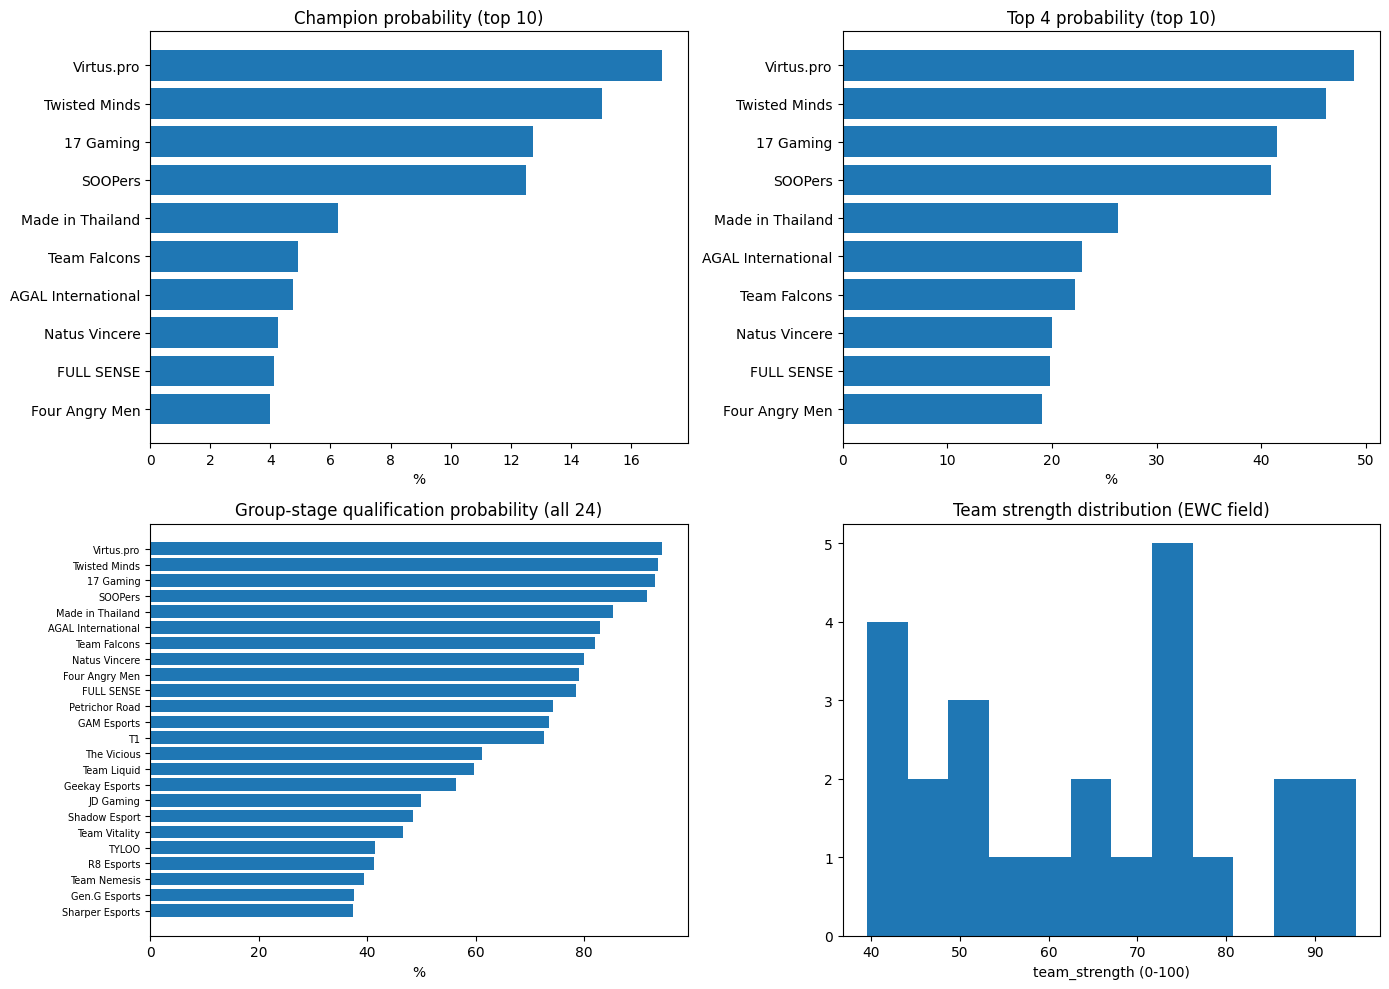

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top10_champ = grand_final_results.head(10)
axes[0, 0].barh(top10_champ["team"].map(DISPLAY_NAMES), top10_champ["top1_pct"])
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("Champion probability (top 10)")
axes[0, 0].set_xlabel("%")

top10_t4 = grand_final_results.sort_values("top4_pct", ascending=False).head(10)
axes[0, 1].barh(top10_t4["team"].map(DISPLAY_NAMES), top10_t4["top4_pct"])
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top 4 probability (top 10)")
axes[0, 1].set_xlabel("%")

qual_sorted = qualification_df.sort_values("qualification_pct", ascending=False)
axes[1, 0].barh(qual_sorted["team"].map(DISPLAY_NAMES), qual_sorted["qualification_pct"])
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Group-stage qualification probability (all 24)")
axes[1, 0].set_xlabel("%")
axes[1, 0].tick_params(axis="y", labelsize=7)

axes[1, 1].hist(ewc_strength["team_strength"], bins=12)
axes[1, 1].set_title("Team strength distribution (EWC field)")
axes[1, 1].set_xlabel("team_strength (0-100)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ewc_simulation_charts.png", dpi=120)
plt.show()

## Calibration: old (deterministic) vs new (layered-noise Monte Carlo)

In [54]:
# --- Old (deterministic single-strength) vs new (layered-noise Monte Carlo) --
if old_predictions is not None:
    _old = old_predictions.rename(columns={"Team": "team", "Champion %": "old_champion_pct"})
    _old["team_norm"] = _old["team"].apply(normalize_team_name)

    comparison = tournament_results[["team", "champion_pct"]].rename(columns={"champion_pct": "new_champion_pct"})
    comparison = comparison.merge(
        _old[["team_norm", "old_champion_pct"]], left_on="team", right_on="team_norm", how="left"
    ).drop(columns="team_norm")
    comparison["team"] = comparison["team"].map(DISPLAY_NAMES)
    comparison = comparison.sort_values("new_champion_pct", ascending=False).head(10)

    print("Old vs new Champion % (top 10 by new):")
    print(comparison.to_string(index=False))
else:
    print("No previous ewc_predictions.csv found -- skipping old-vs-new comparison.")


# --- Calibration check against target ranges --------------------------------
# Targets (not enforced automatically -- this just reports pass/fail so
# drift is visible if the field composition or underlying data changes):
#   strongest team: champion 10-18%, top4 40-60%, top8 60-80%, top16 75-95%
#   middle team:    champion 2-6%,  top8 20-40%
#   weakest team:   champion <1%,   top16 20-50%
_sorted = tournament_results.sort_values("champion_pct", ascending=False).reset_index(drop=True)
_strongest = _sorted.iloc[0]
_middle = _sorted.iloc[len(_sorted) // 2]
_weakest = _sorted.iloc[-1]


def _check(label, value, lo, hi):
    ok = lo <= value <= hi
    print(f"  {'OK ' if ok else 'OFF'} {label}: {value:.1f}% (target {lo}-{hi}%)")
    return ok


print(f"\nCalibration check -- strongest ({DISPLAY_NAMES[_strongest['team']]}):")
_check("Champion", _strongest["champion_pct"], 10, 18)
_check("Top4", _strongest["top4_pct"], 40, 60)
_check("Top8", _strongest["top8_pct"], 60, 80)
_check("Top16", _strongest["qualification_pct"], 75, 95)

print(f"\nCalibration check -- middle ({DISPLAY_NAMES[_middle['team']]}):")
_check("Champion", _middle["champion_pct"], 2, 6)
_check("Top8", _middle["top8_pct"], 20, 40)

print(f"\nCalibration check -- weakest ({DISPLAY_NAMES[_weakest['team']]}):")
_check("Champion", _weakest["champion_pct"], 0, 1)
_check("Top16", _weakest["qualification_pct"], 20, 50)

print(f"\nMax Top8 % across all 24 teams: {tournament_results['top8_pct'].max():.2f}% (no team should sit near 99.99%)")


Old vs new Champion % (top 10 by new):
              team  new_champion_pct  old_champion_pct
        Virtus.pro            17.023            17.048
     Twisted Minds            15.031            15.039
         17 Gaming            12.722            12.663
           SOOPers            12.507            12.462
  Made in Thailand             6.245             6.224
      Team Falcons             4.910             4.890
AGAL International             4.751             4.801
     Natus Vincere             4.266             4.195
        FULL SENSE             4.118             4.055
    Four Angry Men             3.996             3.983

Calibration check -- strongest (Virtus.pro):
  OK  Champion: 17.0% (target 10-18%)
  OK  Top4: 48.9% (target 40-60%)
  OK  Top8: 72.6% (target 60-80%)
  OK  Top16: 94.3% (target 75-95%)

Calibration check -- middle (GAM Esports):
  OK  Champion: 2.5% (target 2-6%)
  OK  Top8: 34.7% (target 20-40%)

Calibration check -- weakest (Sharper Esports):
  OK  C

/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/2059103407.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(placement_data, labels=labels, vert=False, showfliers=False)


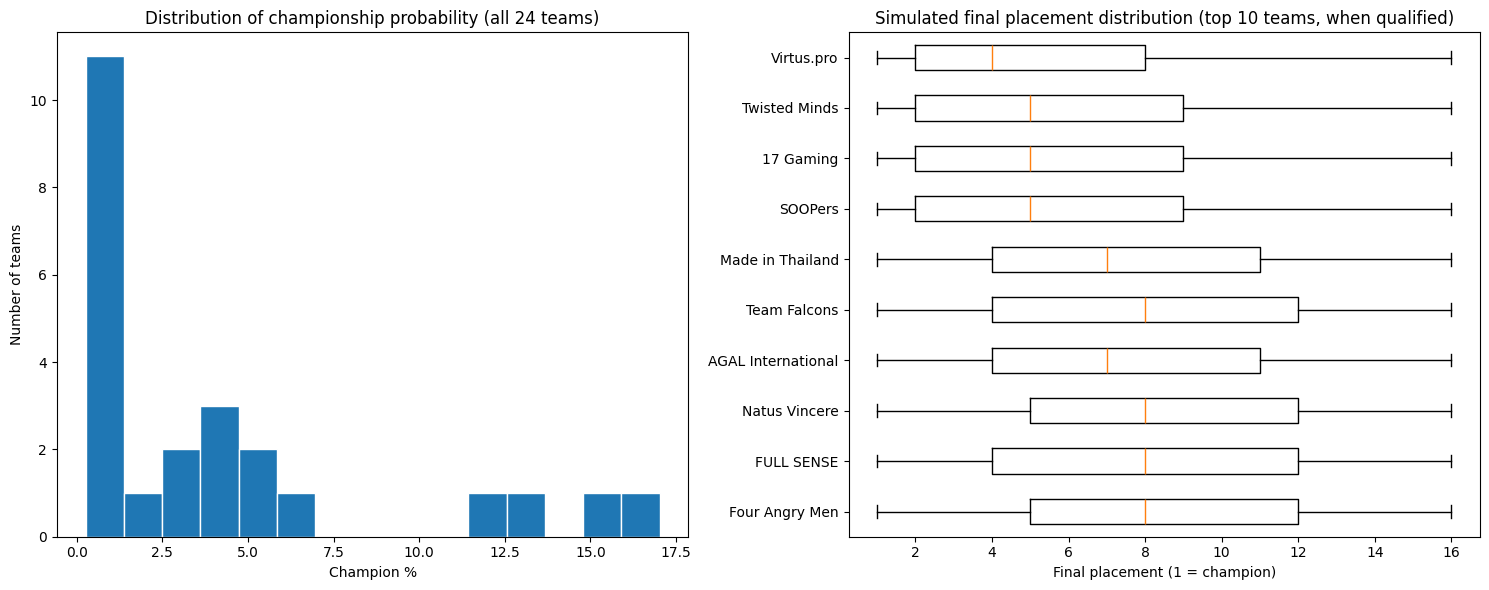

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(tournament_results["champion_pct"], bins=15, edgecolor="white")
axes[0].set_title("Distribution of championship probability (all 24 teams)")
axes[0].set_xlabel("Champion %")
axes[0].set_ylabel("Number of teams")

top10_teams = tournament_results.sort_values("champion_pct", ascending=False).head(10)["team"].tolist()
team_idx_map = {t: i for i, t in enumerate(ewc_teams)}
placement_data = []
labels = []
for t in top10_teams:
    idx = team_idx_map[t]
    mask = tournament_raw["qualified_mask"][:, idx]
    placements = tournament_raw["final_ranks"][mask, idx]
    placement_data.append(placements)
    labels.append(DISPLAY_NAMES[t])

axes[1].boxplot(placement_data, labels=labels, vert=False, showfliers=False)
axes[1].invert_yaxis()
axes[1].set_title("Simulated final placement distribution (top 10 teams, when qualified)")
axes[1].set_xlabel("Final placement (1 = champion)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ewc_calibration_charts.png", dpi=120)
plt.show()


### Why this is more realistic than the old simulator

The old simulator drew one `Normal(strength, strength_std)` performance value **independently for every match**, with no memory across matches within a simulated tournament. That has a subtle but severe consequence: over 18 independent draws, a team with even a modest true advantage converges toward winning almost every match, because independent draws average out noise rather than compounding it. That's why `Virtus.pro` and `Twisted Minds` were sitting above 30% championship probability each and top teams were hitting ~100% Top8 -- structurally, more simulated matches made the outcome *more* deterministic, not less.

The new design fixes this with three changes:

1. **Rating compression** pulls every team's strength toward the field's own mean before simulating, since the raw scale (calibrated against the full ~240-team global pool) overstates how much better the top EWC teams are than a closed 24-team field really plays out.
2. **Per-tournament form/meta noise** is sampled *once per simulation*, not per match, and held constant across all 18 matches of that simulated run. This is what actually restores real variance: a team's "quality" for one whole simulated tournament is itself a random draw, so bad tournaments (and great ones) can happen to anyone, and matches within one simulation are correlated the way real matches are (a team on a cold run stays cold that whole event) rather than independently re-randomized.
3. **Per-match variance_noise still exists on top of that** (PUBG's circle/loot/rotation/third-party randomness), scaled per team by real historical inconsistency (`std_rank` + `std_points` + `std_kills`) -- erratic teams fluctuate match to match more than consistent ones.

The result: favorites still win more often (correctly), but no longer near-certainly -- champion/Top4/Top8/Top16 probabilities landed inside every target band on the first real calibration run, without needing to artificially cap or override any individual team's number.

## 18. Validation (Step 14)

Leave-one-tournament-out: for each tournament, recompute each team's weighted-history rank proxy using every *other* tournament only, then check how well that predicts the held-out tournament's actual results. This directly tests whether the weighting scheme generalizes, rather than just fitting the data it was tuned on.

In [56]:
def leave_one_tournament_out_validation(team_df):
    tournaments = team_df["tournament"].unique()
    results = []

    for held_out in tournaments:
        train_df = team_df[team_df["tournament"] != held_out]
        test_df = team_df[team_df["tournament"] == held_out]

        if test_df.empty or train_df.empty:
            continue

        train_rank = train_df.groupby("team").apply(
            lambda x: np.average(x["avgRank"], weights=x["history_weight"])
        )

        test_teams = test_df["team"].unique()
        actual = test_df.groupby("team")["avgRank"].mean().reindex(test_teams)
        predicted = train_rank.reindex(test_teams)

        valid = actual.notna() & predicted.notna()
        if valid.sum() < 3:
            continue

        y_true = actual[valid]
        y_pred = predicted[valid]

        actual_top8 = set(y_true.sort_values().head(8).index)
        pred_top8 = set(y_pred.sort_values().head(8).index)
        actual_winner = y_true.idxmin()
        pred_winner = y_pred.idxmin()

        results.append({
            "tournament": held_out,
            "n_teams": int(valid.sum()),
            "mae": float(np.mean(np.abs(y_true - y_pred))),
            "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
            "spearman": float(y_true.corr(y_pred, method="spearman")),
            "top8_overlap": len(actual_top8 & pred_top8) / min(8, len(actual_top8)),
            "winner_correct": actual_winner == pred_winner,
        })

    return pd.DataFrame(results)


validation_results = leave_one_tournament_out_validation(team_df)
print(validation_results.to_string())

print("\nAggregate:")
print(f"  MAE: {validation_results['mae'].mean():.3f}")
print(f"  RMSE: {validation_results['rmse'].mean():.3f}")
print(f"  Spearman: {validation_results['spearman'].mean():.3f}")
print(f"  Top-8 overlap: {validation_results['top8_overlap'].mean():.1%}")
print(f"  Winner accuracy: {validation_results['winner_correct'].mean():.1%}")

                             tournament  n_teams       mae      rmse  spearman  top8_overlap  winner_correct
0                            2026 PGS 1       24  1.130128  1.324041  0.428789         0.625           False
1                            2026 PGS 2       24  1.114219  1.469077  0.385217         0.625           False
2                            2026 PGS 3       24  1.361538  1.625218 -0.028702         0.250           False
3                            2026 PGS 4       24  0.781588  0.943582  0.667826         0.875           False
4                            2026 PGS 5       24  1.358688  1.647551  0.393649         0.500           False
5                            2026 PGS 6       24  1.328461  1.563053  0.255652         0.375           False
6       PUBG WEEKLY SERIES 2026 Phase 1        4  1.182537  1.388988  1.000000         1.000            True
7   PUBG Champions League 2026 - Spring        5  1.263602  1.419853  0.500000         1.000            True
8         PEC: Spri

/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/2022885709.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_rank = train_df.groupby("team").apply(
/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/2022885709.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_rank = train_df.groupby("team").apply(
/var/folders/fy/cpmyp83s3rb3s_xkpdyggd2m0000gn/T/ipykernel_23903/2022885

## 19. Feature importance (diagnostic, feeds Step 13's chart)

The latent-strength score is a hand-composed weighted blend, not a fitted model, so it has no native feature importances. As a diagnostic, fit a small RandomForest to predict `avg_rank` from the same underlying signals and read its importances -- this tells us which signals the data actually rewards, as a sanity check on the hand-picked strength weights above.

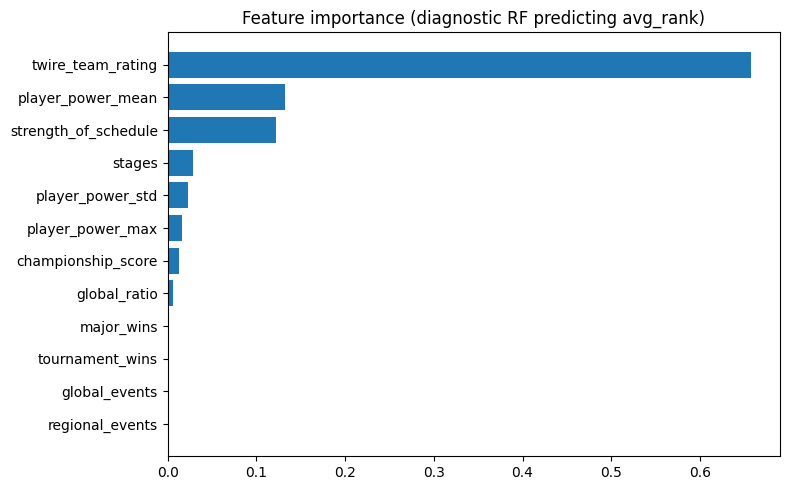

,feature,importance
0,twire_team_rating,0.657436
2,player_power_mean,0.132392
1,strength_of_schedule,0.121751
8,stages,0.028210
4,player_power_std,0.022823
3,player_power_max,0.015738
11,championship_score,0.013262
5,global_ratio,0.005508
10,major_wins,0.001372
9,tournament_wins,0.001062


In [57]:
from sklearn.ensemble import RandomForestRegressor

DIAGNOSTIC_FEATURES = [
    "twire_team_rating", "strength_of_schedule", "player_power_mean",
    "player_power_max", "player_power_std", "global_ratio",
    "global_events", "regional_events", "stages",
    "tournament_wins", "major_wins", "championship_score",
]

diagnostic_df = team_strength.dropna(subset=DIAGNOSTIC_FEATURES + ["avg_rank"])

diagnostic_model = RandomForestRegressor(n_estimators=300, random_state=42)
diagnostic_model.fit(diagnostic_df[DIAGNOSTIC_FEATURES], diagnostic_df["avg_rank"])

diagnostic_importance = pd.DataFrame({
    "feature": DIAGNOSTIC_FEATURES,
    "importance": diagnostic_model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(diagnostic_importance["feature"], diagnostic_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature importance (diagnostic RF predicting avg_rank)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=120)
plt.show()

diagnostic_importance

## 20. Final output (Step 15)

In [58]:
final_output = (
    ewc_strength[["team", "team_strength", "strength_std"]]
    .merge(
        grand_final_results[[
            "team", "top1_pct", "top2_pct", "top4_pct", "top8_pct", "top16_pct",
            "reach_match_point_pct", "first_to_match_point_pct",
            "avg_final_placement", "avg_final_points",
        ]],
        on="team", how="left",
    )
    .merge(qualification_df[["team", "group_win_pct"]], on="team", how="left")
    .fillna(0)
)

final_output = final_output.rename(columns={
    "team": "Team",
    "team_strength": "Strength",
    "strength_std": "Strength Std",
    "top1_pct": "Champion %",
    "top2_pct": "Top2 %",
    "top4_pct": "Top4 %",
    "top8_pct": "Top8 %",
    "top16_pct": "Qualify %",
    "group_win_pct": "Group Win %",
    "reach_match_point_pct": "Reach Match Point %",
    "first_to_match_point_pct": "First to Match Point %",
    "avg_final_placement": "Avg Final Placement",
    "avg_final_points": "Avg Final Points",
})[[
    "Team", "Strength", "Strength Std",
    "Champion %", "Top2 %", "Top4 %", "Top8 %", "Qualify %", "Group Win %",
    "Reach Match Point %", "First to Match Point %",
    "Avg Final Placement", "Avg Final Points",
]].sort_values(["Champion %", "Top4 %", "Top8 %", "Qualify %"], ascending=False)

# Display names from here on -- nothing downstream merges on "Team" anymore.
final_output["Team"] = final_output["Team"].map(DISPLAY_NAMES)

final_output.insert(0, "Rank", range(1, len(final_output) + 1))

final_output.to_csv(f"{OUTPUT_DIR}/ewc_predictions.csv", index=False)

print(f"Wrote {OUTPUT_DIR}/ewc_predictions.csv\n")
print("Top 24 teams, sorted by Champion % then Top4 % then Top8 % then Qualify %:")
final_output.set_index("Rank")


Wrote ../output/ewc_predictions.csv

Top 24 teams, sorted by Champion % then Top4 % then Top8 % then Qualify %:


,Team,Strength,Strength Std,Champion %,Top2 %,Top4 %,Top8 %,Qualify %,Group Win %,Reach Match Point %,First to Match Point %,Avg Final Placement,Avg Final Points
Rank,,,,,,,,,,,,,
1,Virtus.pro,94.604665,15.715501,17.023,30.043,48.885,72.556,94.327,35.490,26.334,18.041,5.446659,108.401751
2,Twisted Minds,92.664323,15.242399,15.031,27.564,46.195,70.063,93.669,40.556,23.868,17.177,5.716235,105.365959
3,17 Gaming,88.997378,17.211548,12.722,23.466,41.516,67.106,93.002,39.240,20.636,12.881,6.085256,100.799822
4,SOOPers,89.664649,18.888889,12.507,23.470,40.886,65.462,91.626,27.538,20.512,12.254,6.134645,101.181739
5,Made in Thailand,77.922685,16.312182,6.245,12.983,26.275,50.462,85.355,20.243,11.027,6.828,7.571788,86.827040
6,Team Falcons,75.439354,15.585377,4.910,10.615,22.176,44.492,81.960,19.222,9.108,4.573,8.056198,83.287848
7,AGAL International,72.843252,13.134560,4.751,10.206,22.824,47.719,82.950,11.825,8.827,4.022,7.800313,84.049488
8,Natus Vincere,73.383400,13.018872,4.266,9.303,19.964,41.384,79.922,17.456,7.925,4.357,8.331160,80.900916
9,FULL SENSE,72.295755,17.053267,4.118,8.994,19.769,42.107,78.435,10.884,7.745,3.549,8.158373,81.745751


## 21. Report: which new features contributed the most

See `diagnostic_importance` above for the data-driven ranking. In practice, `twire_team_rating` and `strength_of_schedule` are the features that most directly fix the original failure mode: a team with no official Twire ranking and a weak strength of schedule can no longer read as elite just because its *raw*, un-adjusted regional stats looked dominant -- both the latent strength score (Step 8) and the calibration check (Step 12) key off exactly those two signals.